# ROBUSTNESS BETWEEN BETA AND ODDS RATIO IMPUTED.
It's neccessary to have the beta and standard error columns in order to run HDL and Mendelian Randomizations. So we need to impute beta and its' standard error from the odds ratio and its' standard error. 
This file will be used to keep track of the modifications done to obtain this test.

1. Create a new csv for only the ones we are going to test.
2. Create the final sumstats file.
3. Copy the files into the new location to avoid overwriting original files.
4. Create script that imputes beta and se of beta.
5. Munge the datasets.
6. Create the paired datasets.
7. Run ldsc.
8. Extract results from ldsc.
9. Compare the results and plot the differences.

In [7]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import csv
import gzip
import shutil
from IPython.display import Image
import subprocess
from collections import Counter
import matplotlib.pyplot as plt


ModuleNotFoundError: No module named 'seaborn'

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


## 1. Create new excell file.
It will contain only 5 examples of datasets containing only OR and those that contain both to compare the results.

In [3]:
excell_original = pd.read_csv("/home/maria/git/SOROLLA/SumStats/excell_sumstats_description.csv")

In [4]:
excell_original.head(2)

,type,selection,title,pubmedId,efoTraits,disease,disease_subtype,label,condition_label,summaryStatistics,id,filename,Ancestry,ref_genome,snp,a1,a2,frq,FRQ_U,FRQ_A,z,b,OR,se,p,N_col,N_num,Nca_col,Nca_val,Nco_col,Nco_val,INFO,ignore
0,NEU,subtype-family,"Genome-wide meta-analysis, fine-mapping and integrative prioritization implicate new Alzheimer's disease risk genes.",33589840,alzheimer's disease,alzheimer's disease,family history,alzheimers-disease-family-history,ALZ,http://ftp.ebi.ac.uk/pub/databases/gwas/summary_statistics/GCST90012001-GCST90013000/GCST90012878/GCST90012878_buildGRCh37.tsv.gz,GCST90012878,GCST90012878.tsv.gz,European,NaN,SNP_ID,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,NaN,standard_error,p_value,NaN,408942,NaN,53042.0,NaN,355900.0,INFO,variant_id
1,NEU,main,"Genetic meta-analysis of diagnosed Alzheimer's disease identifies new risk loci and implicates Aβ, tau, immunity and lipid processing.",30820047,late-onset Alzheimers disease,alzheimer's disease,NaN,alzheimers-late-onset-1,ALZ,http://ftp.ebi.ac.uk/pub/databases/gwas/summary_statistics/GCST007001-GCST008000/GCST007511/Kunkle_etal_Stage1_results.txt,GCST007511,GCST007511.txt,European,NaN,MarkerName,Effect_allele,Non_Effect_allele,NaN,NaN,NaN,NaN,Beta,NaN,SE,Pvalue,NaN,63926,NaN,21982.0,NaN,41944.0,NaN,NaN


In [5]:
excell_original['combination'] = (excell_original['z'].notnull().astype(int).astype(str) + 
                      excell_original['b'].notnull().astype(int).astype(str) + 
                      excell_original['OR'].notnull().astype(int).astype(str))

# Binary representation to see whether the column has a value according to the combination
combination_labels = {
    '100': 'Z-SCORE',
    '010': 'BETA',
    '001': 'ODDS RATIO',
    '110': 'Z-SCORE AND BETA',
    '101': 'Z-SCORE AND ODDS RATIO',
    '011': 'BETA AND ODDS RATIO',
    '111': 'ALL THREE',
	'000': 'NONE'
}
excell_original['combination'] = excell_original['combination'].map(combination_labels)

In [6]:
excell_original['combination'].value_counts()

combination
BETA                      85
ODDS RATIO                13
Z-SCORE AND BETA          12
BETA AND ODDS RATIO        6
NONE                       4
Z-SCORE AND ODDS RATIO     3
Name: count, dtype: int64

In [7]:
## Select the files that contain both beta and OR and their se.
excell_beta_odds = excell_original[excell_original['combination']=="BETA AND ODDS RATIO"]
excell_odds = excell_original[excell_original['combination']=="ODDS RATIO"]
excell_odds = excell_odds.iloc[0:5]

In [8]:
print(excell_odds.shape)
excell_odds.head(2)

(5, 34)


,type,selection,title,pubmedId,efoTraits,disease,disease_subtype,label,condition_label,summaryStatistics,id,filename,Ancestry,ref_genome,snp,a1,a2,frq,FRQ_U,FRQ_A,z,b,OR,se,p,N_col,N_num,Nca_col,Nca_val,Nco_col,Nco_val,INFO,ignore,combination
18,PSY,main,"Genome-wide analyses of attention deficit hyperactivity disorder identify 27 risk loci, refine the genetic architecture, and implicate several cognitive domains",36702997,attention deficit hyperactivity disorder,attention deficit disorder,NaN,ADHD-PGC-2022,ADHD,https://figshare.com/ndownloader/files/40036684,PGC-ADHD-2022,ADHD2022_iPSYCH_deCODE_PGC.meta.gz,"European, Danish",GRCh37,SNP,A1,A2,NaN,FRQ_U_186843,FRQ_A_38691,NaN,NaN,OR,SE,P,N-col,225534,Nca,38691.0,Nco,186843.0,INFO,NaN,ODDS RATIO
23,PSY,main,"Genome-wide association study of more than 40,000 bipolar disorder cases provides new insights into the underlying biology",34002096,bipolar disorder,bipolar disorder,NaN,BIP-PGC-2021,BIP,https://figshare.com/ndownloader/files/40036705,PGC-BIP-2021,PGC-BIP-2021.gz,European,NaN,SNP,A1,A2,NaN,FRQ_U_313436,FRQ_A_40463,NaN,NaN,OR,SE,P,NaN,413466,Nca,41917.0,Nco,371549.0,INFO,NaN,ODDS RATIO


In [9]:
print(excell_beta_odds.shape)
excell_beta_odds.head(2)

(6, 34)


,type,selection,title,pubmedId,efoTraits,disease,disease_subtype,label,condition_label,summaryStatistics,id,filename,Ancestry,ref_genome,snp,a1,a2,frq,FRQ_U,FRQ_A,z,b,OR,se,p,N_col,N_num,Nca_col,Nca_val,Nco_col,Nco_val,INFO,ignore,combination
71,CAN,subtype,Large-scale association analysis identifies new lung cancer susceptibility loci and heterogeneity in genetic susceptibility across histological subtypes.,28604730,squamous cell lung carcinoma,lung cancer,squamous cell,lung-cancer-squamous,LC,http://ftp.ebi.ac.uk/pub/databases/gwas/summary_statistics/GCST004001-GCST005000/GCST004750/GCST004750_buildGRCh37.tsv,GCST004750,GCST004750.tsv,European,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,63053,NaN,7426.0,NaN,55627.0,NaN,NaN,BETA AND ODDS RATIO
73,PSY,minor,Genome-wide gene-environment analyses of major depressive disorder and reported lifetime traumatic experiences in UK Biobank.,31969693,unipolar depression,major depression disorder,NaN,mdd-1,DEP,http://ftp.ebi.ac.uk/pub/databases/gwas/summary_statistics/GCST009001-GCST010000/GCST009979/GCST009979_build37.tsv.gz,GCST009979,GCST009979.tsv.gz,European,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,92957,n_case,29475.0,n_control,63482.0,info,NaN,BETA AND ODDS RATIO


In [10]:
excell_beta_odds_and_only_odds = pd.concat([excell_beta_odds, excell_odds])
print(excell_beta_odds_and_only_odds.shape)
excell_beta_odds_and_only_odds.head(2)

(11, 34)


,type,selection,title,pubmedId,efoTraits,disease,disease_subtype,label,condition_label,summaryStatistics,id,filename,Ancestry,ref_genome,snp,a1,a2,frq,FRQ_U,FRQ_A,z,b,OR,se,p,N_col,N_num,Nca_col,Nca_val,Nco_col,Nco_val,INFO,ignore,combination
71,CAN,subtype,Large-scale association analysis identifies new lung cancer susceptibility loci and heterogeneity in genetic susceptibility across histological subtypes.,28604730,squamous cell lung carcinoma,lung cancer,squamous cell,lung-cancer-squamous,LC,http://ftp.ebi.ac.uk/pub/databases/gwas/summary_statistics/GCST004001-GCST005000/GCST004750/GCST004750_buildGRCh37.tsv,GCST004750,GCST004750.tsv,European,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,63053,NaN,7426.0,NaN,55627.0,NaN,NaN,BETA AND ODDS RATIO
73,PSY,minor,Genome-wide gene-environment analyses of major depressive disorder and reported lifetime traumatic experiences in UK Biobank.,31969693,unipolar depression,major depression disorder,NaN,mdd-1,DEP,http://ftp.ebi.ac.uk/pub/databases/gwas/summary_statistics/GCST009001-GCST010000/GCST009979/GCST009979_build37.tsv.gz,GCST009979,GCST009979.tsv.gz,European,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,92957,n_case,29475.0,n_control,63482.0,info,NaN,BETA AND ODDS RATIO


In [11]:
excell_beta_odds_and_only_odds.to_csv("/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/excell_sumstats_description_imputed_beta_se_from_OR.csv", index=False)

## 2. Create final sumstats description file.

In [12]:
def create_and_append_dataframe(input_file, output_file, desired_columns, test_beta="NA", test_se_beta="NA", munged_default="False", wrangled_default="False", munged_path_default="NA", wrangled_path_default="NA"):
    # Read input data using pandas
    try:
        df_in = pd.read_csv(input_file)
    except FileNotFoundError:
        print(f"Error: Input file {input_file} not found.")
        return
    except pd.errors.ParserError as e:
        print(f"Error parsing input CSV: {e}")
        return
    
    # Select desired columns
    df = df_in[desired_columns]
    print(f"Dataframe after column selection:\n{df.head()}")
    
    # Set paths
    base_path = "/home/maria/git/SOROLLA/SumStats/RAW/"
    test_path = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/"

    # Convert all columns to strings
    df['Nca_val'] = df['Nca_val'].apply(lambda x: str(int(float(x))) if pd.notna(x) else x)
    df['Nco_val'] = df['Nco_val'].apply(lambda x: str(int(float(x))) if pd.notna(x) else x)
    
    # Add new columns with defaults
    df['local_raw_path'] = df.apply(lambda row: os.path.join(base_path, row['filename']), axis=1)
    df["test_raw_path"] = df.apply(lambda row: os.path.join(test_path, row['filename']), axis=1)
    df["test_beta"] = test_beta
    df["test_se_beta"] = test_se_beta 
    df['munged'] = munged_default
    df['local_munged_path'] = munged_path_default

    
    # Handle existing IDs (assuming 'id' is the unique identifier)
    if os.path.exists(output_file):
        try:
            df_existing = pd.read_csv(output_file)
            existing_ids = set(df_existing['id'])
            df = df.loc[~df['id'].isin(existing_ids)]  # Filter out existing IDs
        except FileNotFoundError:
            pass  # No existing file, proceed normally
    
    print(f"Dataframe after filtering existing IDs:\n{df.head()}")
    
    # Append data to output file (create if it doesn't exist)
    print(df.head())
    df.to_csv(output_file, mode='a', header=not os.path.exists(output_file), index=False)
    print(f"Data appended to {output_file}")


In [13]:
desired_columns = ["type", "selection", "id","disease", "disease_subtype", "condition_label", "label", "filename", 
                       "ref_genome", "snp", "a1", "a2", "frq", "FRQ_U", "FRQ_A", 
                       "z", "b", "OR", "se", "p", "N_col", "N_num", "Nca_col", 
                       "Nca_val", "Nco_col", "Nco_val", "INFO", "ignore"]

input_file = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/excell_sumstats_description_imputed_beta_se_from_OR.csv"
output_file = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/final_sumstats_description_imputed_beta_se_from_OR.csv"


In [14]:
create_and_append_dataframe(input_file, output_file, desired_columns, munged_default="False", wrangled_default="False", munged_path_default="NA", wrangled_path_default="NA")


Dataframe after column selection:
  type selection          id                    disease disease_subtype  \
0  CAN   subtype  GCST004750                lung cancer   squamous cell   
1  PSY     minor  GCST009979  major depression disorder             NaN   
2  PSY   subtype  GCST009980  major depression disorder          trauma   
3  PSY   subtype  GCST009981  major depression disorder       no trauma   
4  NEU      main  GCST001198         multiple sclerosis             NaN   

  condition_label                 label           filename ref_genome  \
0              LC  lung-cancer-squamous     GCST004750.tsv     GRCh37   
1             DEP                 mdd-1  GCST009979.tsv.gz     GRCh37   
2             DEP            mdd-trauma  GCST009980.tsv.gz     GRCh37   
3             DEP          mdd-notrauma  GCST009981.tsv.gz     GRCh37   
4            SCLE  multiple-sclerosis-2  GCST001198.tsv.gz        NaN   

          snp             a1            a2                      frq FRQ_U  \

/tmp/ipykernel_197404/21895110.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Nca_val'] = df['Nca_val'].apply(lambda x: str(int(float(x))) if pd.notna(x) else x)
/tmp/ipykernel_197404/21895110.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Nco_val'] = df['Nco_val'].apply(lambda x: str(int(float(x))) if pd.notna(x) else x)
/tmp/ipykernel_197404/21895110.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer

## 3.Copy the original files into a folder to avoid overwritting

IMPORTANT INFORMATION!!!!
ONLY RE-RUN THIS PART IF THE TEST IS BEING RE-RUN FROM THE BEGINNING, OTHERWISE IT WILL OVERWRITE THE PART WHERE NEW COLUMNS ARE ADDED.

In [15]:
# Load the recently created dataset.

final_description = pd.read_csv("/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/final_sumstats_description_imputed_beta_se_from_OR.csv")

In [16]:
display(final_description)

,type,selection,id,disease,disease_subtype,condition_label,label,filename,ref_genome,snp,a1,a2,frq,FRQ_U,FRQ_A,z,b,OR,se,p,N_col,N_num,Nca_col,Nca_val,Nco_col,Nco_val,INFO,ignore,local_raw_path,test_raw_path,test_beta,test_se_beta,munged,local_munged_path
0,CAN,subtype,GCST004750,lung cancer,squamous cell,LC,lung-cancer-squamous,GCST004750.tsv,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,63053,NaN,7426,NaN,55627,NaN,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST004750.tsv,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST004750.tsv,NaN,NaN,False,NaN
1,PSY,minor,GCST009979,major depression disorder,NaN,DEP,mdd-1,GCST009979.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,92957,n_case,29475,n_control,63482,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009979.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009979.tsv.gz,NaN,NaN,False,NaN
2,PSY,subtype,GCST009980,major depression disorder,trauma,DEP,mdd-trauma,GCST009980.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,24094,n_case,13393,n_control,10701,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009980.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009980.tsv.gz,NaN,NaN,False,NaN
3,PSY,subtype,GCST009981,major depression disorder,no trauma,DEP,mdd-notrauma,GCST009981.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,49164,n_case,9487,n_control,39677,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009981.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009981.tsv.gz,NaN,NaN,False,NaN
4,NEU,main,GCST001198,multiple sclerosis,NaN,SCLE,multiple-sclerosis-2,GCST001198.tsv.gz,NaN,rsid,effect_allele,other_allele,NaN,NaN,NaN,NaN,beta,OR,se,p,NaN,26621,NaN,9772,NaN,16849,NaN,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST001198.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST001198.tsv.gz,NaN,NaN,False,NaN
5,CAN,subtype,GCST90137411,skin cancer,basal cell,SKIN,bcc-2,GCST90137411.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,307684,NaN,20791,NaN,286893,NaN,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST90137411.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST90137411.tsv.gz,NaN,NaN,False,NaN
6,PSY,main,PGC-ADHD-2022,attention deficit disorder,NaN,ADHD,ADHD-PGC-2022,ADHD2022_iPSYCH_deCODE_PGC.meta.gz,GRCh37,SNP,A1,A2,NaN,FRQ_U_186843,FRQ_A_38691,NaN,NaN,OR,SE,P,N-col,225534,Nca,38691,Nco,186843,INFO,NaN,/home/maria/git/SOROLLA/SumStats/RAW/ADHD2022_iPSYCH_deCODE_PGC.meta.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/ADHD2022_iPSYCH_deCODE_PGC.meta.gz,NaN,NaN,False,NaN
7,PSY,main,PGC-BIP-2021,bipolar disorder,NaN,BIP,BIP-PGC-2021,PGC-BIP-2021.gz,NaN,SNP,A1,A2,NaN,FRQ_U_313436,FRQ_A_40463,NaN,NaN,OR,SE,P,NaN,413466,Nca,41917,Nco,371549,INFO,NaN,/home/maria/git/SOROLLA/SumStats/RAW/PGC-BIP-2021.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/PGC-BIP-2021.gz,NaN,NaN,False,NaN
8,PSY,minor,GCST001241,bipolar disorder,NaN,BIP,BIP-PGC-2011,GCST001241.gz,NaN,snpid,a1,a2,NaN,NaN,NaN,NaN,NaN,or,se,pval,NaN,16731,NaN,7481,NaN,9250,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST001241.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST001241.gz,NaN,NaN,False,NaN
9,CAN,minor,GCST90011804,breast cancer,carcinoma,BRCA,breast-carcinoma-1,GCST90011804.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,NaN,NaN,NaN,NaN,NaN,odds_ratio,NaN,p_value,totN,428231,NaN,17881,NaN,410350,NaN,n,/home/maria/git/SOROLLA/SumStats/RAW/GCST90011804.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/

In [17]:
## THIS HAS BEEN ADDED IN THE FUNCTION BEFORE BECAUSE IT WAS BETTER ORDERED AND AVOIDED UNECCESARY CODE.
## ALSO ADDED TWO NEW COLUMNS TO BE ABLE TO COMPARE THE COLUMNS AFTER BEING ADDED.

# test_path = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/"

# final_description["test_raw_path"] = final_description.apply(lambda row: os.path.join(test_path, row['filename']), axis=1)

In [18]:
# Check that the new filepaths are correct
print(final_description["test_raw_path"].tolist())

['/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST004750.tsv', '/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009979.tsv.gz', '/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009980.tsv.gz', '/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009981.tsv.gz', '/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST001198.tsv.gz', '/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST90137411.tsv.gz', '/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/ADHD2022_iPSYCH_deCODE_PGC.meta.gz', '/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/PGC-BIP-2021.gz', '/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST001241.gz', '/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST90011804.tsv.gz', '/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST90011816.tsv.gz']


#### ONLY RE-RUN IF NECESSARY PLEASE CHECK!

In [19]:
for index, row in final_description.iterrows():
    src = row['local_raw_path']
    dst = row['test_raw_path']
    shutil.copy(src, dst)


## 4. Script to add beta and se from ODDS ratio.


In [20]:
## Load again the csv
csv_file_path = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/final_sumstats_description_imputed_beta_se_from_OR.csv"
final_description = pd.read_csv(csv_file_path)

In [21]:
final_description

,type,selection,id,disease,disease_subtype,condition_label,label,filename,ref_genome,snp,a1,a2,frq,FRQ_U,FRQ_A,z,b,OR,se,p,N_col,N_num,Nca_col,Nca_val,Nco_col,Nco_val,INFO,ignore,local_raw_path,test_raw_path,test_beta,test_se_beta,munged,local_munged_path
0,CAN,subtype,GCST004750,lung cancer,squamous cell,LC,lung-cancer-squamous,GCST004750.tsv,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,63053,NaN,7426,NaN,55627,NaN,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST004750.tsv,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST004750.tsv,NaN,NaN,False,NaN
1,PSY,minor,GCST009979,major depression disorder,NaN,DEP,mdd-1,GCST009979.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,92957,n_case,29475,n_control,63482,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009979.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009979.tsv.gz,NaN,NaN,False,NaN
2,PSY,subtype,GCST009980,major depression disorder,trauma,DEP,mdd-trauma,GCST009980.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,24094,n_case,13393,n_control,10701,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009980.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009980.tsv.gz,NaN,NaN,False,NaN
3,PSY,subtype,GCST009981,major depression disorder,no trauma,DEP,mdd-notrauma,GCST009981.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,49164,n_case,9487,n_control,39677,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009981.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009981.tsv.gz,NaN,NaN,False,NaN
4,NEU,main,GCST001198,multiple sclerosis,NaN,SCLE,multiple-sclerosis-2,GCST001198.tsv.gz,NaN,rsid,effect_allele,other_allele,NaN,NaN,NaN,NaN,beta,OR,se,p,NaN,26621,NaN,9772,NaN,16849,NaN,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST001198.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST001198.tsv.gz,NaN,NaN,False,NaN
5,CAN,subtype,GCST90137411,skin cancer,basal cell,SKIN,bcc-2,GCST90137411.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,307684,NaN,20791,NaN,286893,NaN,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST90137411.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST90137411.tsv.gz,NaN,NaN,False,NaN
6,PSY,main,PGC-ADHD-2022,attention deficit disorder,NaN,ADHD,ADHD-PGC-2022,ADHD2022_iPSYCH_deCODE_PGC.meta.gz,GRCh37,SNP,A1,A2,NaN,FRQ_U_186843,FRQ_A_38691,NaN,NaN,OR,SE,P,N-col,225534,Nca,38691,Nco,186843,INFO,NaN,/home/maria/git/SOROLLA/SumStats/RAW/ADHD2022_iPSYCH_deCODE_PGC.meta.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/ADHD2022_iPSYCH_deCODE_PGC.meta.gz,NaN,NaN,False,NaN
7,PSY,main,PGC-BIP-2021,bipolar disorder,NaN,BIP,BIP-PGC-2021,PGC-BIP-2021.gz,NaN,SNP,A1,A2,NaN,FRQ_U_313436,FRQ_A_40463,NaN,NaN,OR,SE,P,NaN,413466,Nca,41917,Nco,371549,INFO,NaN,/home/maria/git/SOROLLA/SumStats/RAW/PGC-BIP-2021.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/PGC-BIP-2021.gz,NaN,NaN,False,NaN
8,PSY,minor,GCST001241,bipolar disorder,NaN,BIP,BIP-PGC-2011,GCST001241.gz,NaN,snpid,a1,a2,NaN,NaN,NaN,NaN,NaN,or,se,pval,NaN,16731,NaN,7481,NaN,9250,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST001241.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST001241.gz,NaN,NaN,False,NaN
9,CAN,minor,GCST90011804,breast cancer,carcinoma,BRCA,breast-carcinoma-1,GCST90011804.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,NaN,NaN,NaN,NaN,NaN,odds_ratio,NaN,p_value,totN,428231,NaN,17881,NaN,410350,NaN,n,/home/maria/git/SOROLLA/SumStats/RAW/GCST90011804.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/

##### Check separator in another function.
I have been having issues with modifying the files that are not tsv.gz, I am unsure why but it is highly likely that it's due to the separator given by the function.
I don't want to assume that the separator is tab-separated when the only extension is .gz so I have modified a function from stack overflow to retrieve the separator.

In [22]:
# # There's an issue with modifying some files. So instead of using if dataset.endswith("") let's try to figure it out with a function
# # That way we can use the designed separator to correctly handle the dataset
# # A function from stack overflow seems reasonable. Link: https://stackoverflow.com/questions/3952132/how-do-you-dynamically-identify-unknown-delimiters-in-a-data-file

def get_delimiter(file_path: str, sample_size : int = 4096) -> str:
    
    # # with open(file_path, 'r') as csvfile:
    # # This does not work well because it assumes they are not compressed.
    # Check if the file is zip compressed, without it, an error is raised.

    if file_path.endswith('.gz'):
        with gzip.open(file_path, 'rt') as csvfile:
            sample = csvfile.read(sample_size)  # Read a sample to detect delimiter
    else:
        with open(file_path, 'r') as csvfile:
            sample = csvfile.read(sample_size)
    
    try:
        # # delimiter = str(csv.Sniffer().sniff(csvfile.read()).delimiter)
        # # This version was giving some errors.
        delimiter = csv.Sniffer().sniff(sample).delimiter
    except csv.Error:
        # # Fallback based on file extension
        # # delimiter = '\t' if file_path.endswith('.tsv') or file_path.endswith('.tsv.gz') else ','
        # # This delimiter is too strict and might miss other values.
        # # Let's try counting the values to avoid assumptions.
        
        potential_delimiters = ['\t', ',', ';', ' ', '|']
        delimiter_counts = Counter(char for char in sample if char in potential_delimiters)
        
        if file_path.endswith('.tsv') or file_path.endswith('.tsv.gz'):
            delimiter = '\t'
        elif delimiter_counts:
            delimiter, _ = delimiter_counts.most_common(1)[0]
        else:
            raise ValueError("Could not determine delimiter reliably.")
    
    return delimiter


In [23]:
separator = get_delimiter("/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/ADHD2022_iPSYCH_deCODE_PGC.meta.gz")
print("The separator is:","'",{separator},"'")

separator = get_delimiter("/home/maria/git/SOROLLA/SumStats/RAW/GCST001198.tsv.gz")
print("The separator is:","'",{separator},"'")

separator = get_delimiter("/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST004750.tsv")
print("The separator is:","'",{separator},"'")


The separator is: ' {' '} '
The separator is: ' {'\t'} '
The separator is: ' {'\t'} '


##### Function to add beta and standard error.
Sometimes se is not present so we need to modify the script later on once the issue with the separators is fixed and the datasets are correctly modified.

In [24]:
def calculate_beta_and_se(data, or_col, se_col=None):
    """Calculate beta and SE_beta for each row in the dataset"""
    # # """Sometimes standard error is not present. Skip for now, 
    # #     we will work out adding standard error once the functions
    # #     work correctly on meta.gz and .gz files."""
    
    # # Check if 'OR' is already numeric
    try:
        if not np.issubdtype(data[or_col].dtype, np.number):
            data[or_col] = pd.to_numeric(data[or_col], errors='coerce')
        if se_col and se_col in data.columns and not np.issubdtype(data[se_col].dtype, np.number):
            data[se_col] = pd.to_numeric(data[se_col], errors='coerce')
        print("The data has been converted to numeric")
    
    
    except Exception as e:
        print(f"Error converting {or_col} and {se_col} to numeric: {e}")
        return data


    print("The data has been converted to numeric or was considered numeric")
    
    # # In the instance to avoid errors that arise when the value for OR is missing, let's remove them.
    # # It's important that when implementing this function, depending on what value we are imputing and what column as reference,
    # # we will need drop more NAs.
    data = data.dropna(subset=[or_col])

    try:
        data['beta_added'] = np.log(data[or_col])
        if se_col and se_col in data.columns:
            upperboundOR = data[or_col] + 1.96 * data[se_col]
            lowerboundOR = data[or_col] - 1.96 * data[se_col]
            upperboundbeta = np.log(upperboundOR)
            lowerboundbeta = np.log(lowerboundOR)
            data['sebeta'] = (upperboundbeta - lowerboundbeta) / (2 * 1.96)
        
        # # Modify this later on, to also impute standard error and name it something else.
        # # At the moment focus on this modifying all the files.
        # # Later on add lines to add se_imputed to compare whether it changes from the originally used when se is not present in the dataset

        else:
            data['sebeta'] = np.nan
    except Exception as e:
        print(f"Error calculating beta and SE: {e}")
        return data
    
    
    return data

In [25]:
def update_main_csv(row):
    file_path = row['test_raw_path']
    # # To have checkpoints of what the function is doing let's add print statements
    print("The file path is:",{file_path})

    # # Print statements to check whether the data has been already added, or just some columns.
    if pd.notna(row.get('test_beta')) and pd.notna(row.get('test_se_beta')):
        print(f"The columns test_beta and test_se_beta have already been added, skipping the dataset {row['label']}")
        return row
    elif pd.notna(row.get('test_beta')):
        print(f"The column test_beta has already been added, adding only test_se_beta for dataset {row['label']}")
    elif pd.notna(row.get('test_se_beta')):
        print(f"The column test_se_beta has already been added, adding only test_beta for dataset {row['label']}")
    
    # # Check the compression file for the pd.read_csv()
    compression = 'gzip' if file_path.endswith('.gz') else None
    print(f"The compression file is:",compression)
    # # With the previously defined function, check the separator for the pd.read_csv()
    separator = get_delimiter(file_path)
    print(f"The dataset separator is: '{separator}'")

    # # Let's start the processing with the function.
    # # First read the data
    print("Opening the dataset")

    try:
        data = pd.read_csv(file_path, sep=separator, compression=compression)
        print(f"This is the unmodified version for the dataset {row['id']}_{row['label']}")
        print(data.head(2))
        print(data.dtypes)

    except EOFError:
        print(f"Warning: File {file_path} is corrupted or incomplete.")
        return row
    
    except Exception as e:
        print(f"Error reading file {file_path}: {e}")
        return row
    
    or_col = row["OR"]
    se_col = row.get('se', None)  # Default to None if 'se' column isn't specified


    if or_col not in data.columns:
        print(f"Column '{or_col}' is required but not found in the dataset {row['label']}")
        return row
    
    # # Use the function defined to calculate the new fileds
    print("Calculating beta and standard error")

    data = calculate_beta_and_se(data, or_col, se_col)
    print(f"This is the modified version for the dataset {row['id']}_{row['label']}")
    print(data.head(2))

    try:
        print("The dataset is being saved")
        data.to_csv(file_path, sep=separator, index=False, compression=compression)
        print(f"Dataset {file_path} has been modified with beta and SE columns.")
        
        # # Check what fields need to be updated
        print("Saving the modification to the row of the reference csv")
        if pd.isna(row.get('test_beta')):
            row['test_beta'] = "beta_added"
        if pd.isna(row.get('test_se_beta')) and 'sebeta' in data.columns:
            row['test_se_beta'] = "sebeta"

        # # Update the csv after every iteration
        csv_to_update = pd.read_csv(file_path)
        csv_to_update.update(pd.DataFrame([row]))
        csv_to_update.to_csv(main_csv_path, index=False, sep=',')

    except Exception as e:
        print(f"Error writing file {file_path}: {e}")
    
    return row


In [26]:
def process_main_csv(file_path):
    df = pd.read_csv(file_path)
    df = df.apply(lambda row: update_main_csv(row), axis=1)
    df.to_csv(file_path, index=False, sep=',')

In [27]:
process_main_csv(csv_file_path)


The file path is: {'/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST004750.tsv'}
The compression file is: None
The dataset separator is: '	'
Opening the dataset
This is the unmodified version for the dataset GCST004750_lung-cancer-squamous
   variant_id   p_value  chromosome  base_pair_location  odds_ratio  ci_lower  \
0   rs2977608  0.075388           1              768253    0.947929  0.893668   
1  rs12562034  0.586376           1              768448    0.979034  0.907089   

   ci_upper      beta  standard_error effect_allele other_allele  \
0  1.005485 -0.053476        0.030075             A            C   
1  1.056686 -0.021188        0.038943             A            G   

   effect_allele_frequency  
0                 0.262464  
1                 0.113446  
variant_id                  object
p_value                    float64
chromosome                   int64
base_pair_location           int64
odds_ratio                 float64
ci_lower                   f

/home/maria/anaconda3/envs/gencor/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


This is the modified version for the dataset GCST004750_lung-cancer-squamous
   variant_id   p_value  chromosome  base_pair_location  odds_ratio  ci_lower  \
0   rs2977608  0.075388           1              768253    0.947929  0.893668   
1  rs12562034  0.586376           1              768448    0.979034  0.907089   

   ci_upper      beta  standard_error effect_allele other_allele  \
0  1.005485 -0.053476        0.030075             A            C   
1  1.056686 -0.021188        0.038943             A            G   

   effect_allele_frequency  beta_added    sebeta  
0                 0.262464   -0.053476  0.031768  
1                 0.113446   -0.021189  0.039858  
The dataset is being saved
Dataset /home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST004750.tsv has been modified with beta and SE columns.
Saving the modification to the row of the reference csv
Error writing file /home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST004750.tsv: name '

/tmp/ipykernel_197404/2727597011.py:27: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path, sep=separator, compression=compression)
/home/maria/anaconda3/envs/gencor/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


This is the unmodified version for the dataset GCST001198_multiple-sclerosis-2
  chrom      pos        rsid other_allele effect_allele       p      beta  \
0     1   768448  rs12562034            G             A  0.3923 -0.023985   
1     1  1005806   rs3934834            G             A  0.8706  0.003793   

         se      OR  OR_lower  OR_upper  
0  0.028038  0.9763  0.924095  1.031454  
1  0.023283  1.0038  0.959020  1.050670  
chrom             object
pos                int64
rsid              object
other_allele      object
effect_allele     object
p                float64
beta             float64
se               float64
OR               float64
OR_lower         float64
OR_upper         float64
dtype: object
Calculating beta and standard error
The data has been converted to numeric
The data has been converted to numeric or was considered numeric
This is the modified version for the dataset GCST001198_multiple-sclerosis-2
  chrom      pos        rsid other_allele effect_allele  

/tmp/ipykernel_197404/2727597011.py:27: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path, sep=separator, compression=compression)


This is the unmodified version for the dataset PGC-BIP-2021_BIP-PGC-2021
  CHR        SNP           BP A1 A2  FRQ_A_40463  FRQ_U_313436   INFO  \
0   1  rs2582784  120324506.0  G  A        0.703         0.689  0.990   
1   1   rs478450  120233922.0  G  A        0.428         0.421  0.997   

        OR      SE       P  ngt  \
0  0.99134  0.0104  0.4036  1.0   
1  0.99880  0.0094  0.8982  1.0   

                                                  Direction  HetISqt  HetDf  \
0  --+-++-++-+-+-+-++++?++++--++-++++-++-+-+---+-++++-++-++      6.2   54.0   
1  -++++-+-++---+-+-+--++--++-+-----++-+-++-+-+++++--++++-+     22.1   55.0   

   HetPVa      Nca       Nco  Neff_half  
0  0.3451  39543.0  312463.0   47198.70  
1  0.0763  40463.0  313436.0   48144.46  
CHR              object
SNP              object
BP              float64
A1               object
A2               object
FRQ_A_40463     float64
FRQ_U_313436    float64
INFO            float64
OR              float64
SE              float

In [28]:
# # For some reason it has not worked for one dataset. So I will manually do it.

dataset = '/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST001241.gz'
or_col = 'or'  
se_col = 'se' 

# Read the gzipped txt file with whitespace separation
with gzip.open(dataset, 'rt') as f:
    data = pd.read_csv(f, delim_whitespace=True)

# Add the columns as specified
data['beta_added'] = np.log(data[or_col])
if se_col in data.columns:
    upperboundOR = data[or_col] + 1.96 * data[se_col]
    lowerboundOR = data[or_col] - 1.96 * data[se_col]
    upperboundbeta = np.log(upperboundOR)
    lowerboundbeta = np.log(lowerboundOR)
    data['sebeta'] = (upperboundbeta - lowerboundbeta) / (2 * 1.96)
else:
    data['sebeta'] = np.nan

# Display the modified data
print(data.head())

# Save the modified data back as tsv gz
with gzip.open(dataset, 'wt') as f:
    data.to_csv(f, sep='\t', index=False)


/tmp/ipykernel_197404/122403193.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(f, delim_whitespace=True)
/home/maria/anaconda3/envs/gencor/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


        snpid  hg18chr      bp a1 a2      or      se    pval    info  ngt  \
0  rs12565286        1  711153  C  G  0.9887  0.0821  0.8899  0.3693    0   
1  rs11804171        1  713682  A  T  0.9887  0.0821  0.8899  0.3693    0   
2   rs2977670        1  713754  C  G  1.0110  0.0822  0.8936  0.3684    0   
3  rs12138618        1  740098  A  G  1.1241  0.0927  0.2069  0.2765    0   
4   rs3094315        1  742429  A  G  1.0037  0.0353  0.9175  0.7758    0   

     CEUaf  beta_added    sebeta  
0   0.0678   -0.011364  0.083783  
1        .   -0.011364  0.083783  
2        .    0.010940  0.082005  
3  0.05833    0.116983  0.083196  
4   0.8448    0.003693  0.035226  


## 5. Munge the datasets

They need to be munged for OR, original BETA, and added BETA and SE. Because the reference csv only has one, it's important that we modify it before so we can have all of them in the same csv. The idea is to, for file, copy the row, and add a colum that specifies what column will be used a summary statistics.


### 5.1. Modify the reference csv and create a new one from it.
- Copy the rows for as many times as columns they have.

In [29]:
## Load again the csv
csv_file_path = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/final_sumstats_description_imputed_beta_se_from_OR.csv"
final_description = pd.read_csv(csv_file_path)

In [30]:
final_description

,type,selection,id,disease,disease_subtype,condition_label,label,filename,ref_genome,snp,a1,a2,frq,FRQ_U,FRQ_A,z,b,OR,se,p,N_col,N_num,Nca_col,Nca_val,Nco_col,Nco_val,INFO,ignore,local_raw_path,test_raw_path,test_beta,test_se_beta,munged,local_munged_path
0,CAN,subtype,GCST004750,lung cancer,squamous cell,LC,lung-cancer-squamous,GCST004750.tsv,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,63053,NaN,7426,NaN,55627,NaN,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST004750.tsv,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST004750.tsv,beta_added,sebeta,False,NaN
1,PSY,minor,GCST009979,major depression disorder,NaN,DEP,mdd-1,GCST009979.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,92957,n_case,29475,n_control,63482,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009979.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009979.tsv.gz,beta_added,sebeta,False,NaN
2,PSY,subtype,GCST009980,major depression disorder,trauma,DEP,mdd-trauma,GCST009980.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,24094,n_case,13393,n_control,10701,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009980.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009980.tsv.gz,beta_added,sebeta,False,NaN
3,PSY,subtype,GCST009981,major depression disorder,no trauma,DEP,mdd-notrauma,GCST009981.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,49164,n_case,9487,n_control,39677,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009981.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009981.tsv.gz,beta_added,sebeta,False,NaN
4,NEU,main,GCST001198,multiple sclerosis,NaN,SCLE,multiple-sclerosis-2,GCST001198.tsv.gz,NaN,rsid,effect_allele,other_allele,NaN,NaN,NaN,NaN,beta,OR,se,p,NaN,26621,NaN,9772,NaN,16849,NaN,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST001198.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST001198.tsv.gz,beta_added,sebeta,False,NaN
5,CAN,subtype,GCST90137411,skin cancer,basal cell,SKIN,bcc-2,GCST90137411.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,307684,NaN,20791,NaN,286893,NaN,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST90137411.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST90137411.tsv.gz,beta_added,sebeta,False,NaN
6,PSY,main,PGC-ADHD-2022,attention deficit disorder,NaN,ADHD,ADHD-PGC-2022,ADHD2022_iPSYCH_deCODE_PGC.meta.gz,GRCh37,SNP,A1,A2,NaN,FRQ_U_186843,FRQ_A_38691,NaN,NaN,OR,SE,P,N-col,225534,Nca,38691,Nco,186843,INFO,NaN,/home/maria/git/SOROLLA/SumStats/RAW/ADHD2022_iPSYCH_deCODE_PGC.meta.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/ADHD2022_iPSYCH_deCODE_PGC.meta.gz,beta_added,sebeta,False,NaN
7,PSY,main,PGC-BIP-2021,bipolar disorder,NaN,BIP,BIP-PGC-2021,PGC-BIP-2021.gz,NaN,SNP,A1,A2,NaN,FRQ_U_313436,FRQ_A_40463,NaN,NaN,OR,SE,P,NaN,413466,Nca,41917,Nco,371549,INFO,NaN,/home/maria/git/SOROLLA/SumStats/RAW/PGC-BIP-2021.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/PGC-BIP-2021.gz,beta_added,sebeta,False,NaN
8,PSY,minor,GCST001241,bipolar disorder,NaN,BIP,BIP-PGC-2011,GCST001241.gz,NaN,snpid,a1,a2,NaN,NaN,NaN,NaN,NaN,or,se,pval,NaN,16731,NaN,7481,NaN,9250,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST001241.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST001241.gz,beta_added,sebeta,False,NaN
9,CAN,minor,GCST90011804,breast cancer,carcinoma,BRCA,breast-carcinoma-1,GCST90011804.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,NaN,NaN,NaN,NaN,NaN,odds_ratio,NaN,p_value,totN,428231,NaN,17881,NaN,410350,NaN,n,/home/ma

In [31]:
def duplicate_and_filter_rows(df):
    # Ensure necessary columns exist
    for col in ['b', 'OR', 'test_beta']:
        if col not in df.columns:
            df[col] = np.nan
    
    rows_to_add = []
    
    for _, row in df.iterrows():
        # Check the conditions for duplication
        conditions = [
            not pd.isna(row['b']) and not pd.isna(row['OR']) and not pd.isna(row['test_beta']),
            not pd.isna(row['b']) and not pd.isna(row['OR']),
            not pd.isna(row['OR']) and not pd.isna(row['test_beta']),
            not pd.isna(row['b']) and not pd.isna(row['test_beta'])
        ]
        
        if conditions[0]:  # All three are present
            row_b = row.copy()
            row_or = row.copy()
            row_test_beta = row.copy()
            row_or['b'] = np.nan
            row_test_beta['b'] = np.nan
            row_b['OR'] = np.nan
            row_test_beta['OR'] = np.nan
            row_b['test_beta'] = np.nan
            row_or['test_beta'] = np.nan
            rows_to_add.extend([row_b, row_or, row_test_beta])
        elif conditions[1]:  # b and OR are present
            row_b = row.copy()
            row_or = row.copy()
            row_or['b'] = np.nan
            row_b['OR'] = np.nan
            rows_to_add.extend([row_b, row_or])
        elif conditions[2]:  # OR and test_beta are present
            row_or = row.copy()
            row_test_beta = row.copy()
            row_or['test_beta'] = np.nan
            row_test_beta['OR'] = np.nan
            rows_to_add.extend([row_or, row_test_beta])
        elif conditions[3]:  # b and test_beta are present
            row_b = row.copy()
            row_test_beta = row.copy()
            row_test_beta['b'] = np.nan
            row_b['test_beta'] = np.nan
            rows_to_add.extend([row_b, row_test_beta])
        else:
            rows_to_add.append(row)

    # Create a new DataFrame from the rows to add
    new_df = pd.DataFrame(rows_to_add, columns=df.columns)
    return new_df

In [32]:
copied_final_description = duplicate_and_filter_rows(final_description)

In [33]:
display(copied_final_description)

,type,selection,id,disease,disease_subtype,condition_label,label,filename,ref_genome,snp,a1,a2,frq,FRQ_U,FRQ_A,z,b,OR,se,p,N_col,N_num,Nca_col,Nca_val,Nco_col,Nco_val,INFO,ignore,local_raw_path,test_raw_path,test_beta,test_se_beta,munged,local_munged_path
0,CAN,subtype,GCST004750,lung cancer,squamous cell,LC,lung-cancer-squamous,GCST004750.tsv,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,NaN,standard_error,p_value,NaN,63053,NaN,7426,NaN,55627,NaN,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST004750.tsv,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST004750.tsv,NaN,sebeta,False,NaN
0,CAN,subtype,GCST004750,lung cancer,squamous cell,LC,lung-cancer-squamous,GCST004750.tsv,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,NaN,odds_ratio,standard_error,p_value,NaN,63053,NaN,7426,NaN,55627,NaN,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST004750.tsv,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST004750.tsv,NaN,sebeta,False,NaN
0,CAN,subtype,GCST004750,lung cancer,squamous cell,LC,lung-cancer-squamous,GCST004750.tsv,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,NaN,NaN,standard_error,p_value,NaN,63053,NaN,7426,NaN,55627,NaN,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST004750.tsv,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST004750.tsv,beta_added,sebeta,False,NaN
1,PSY,minor,GCST009979,major depression disorder,NaN,DEP,mdd-1,GCST009979.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,NaN,standard_error,p_value,NaN,92957,n_case,29475,n_control,63482,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009979.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009979.tsv.gz,NaN,sebeta,False,NaN
1,PSY,minor,GCST009979,major depression disorder,NaN,DEP,mdd-1,GCST009979.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,NaN,odds_ratio,standard_error,p_value,NaN,92957,n_case,29475,n_control,63482,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009979.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009979.tsv.gz,NaN,sebeta,False,NaN
1,PSY,minor,GCST009979,major depression disorder,NaN,DEP,mdd-1,GCST009979.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,NaN,NaN,standard_error,p_value,NaN,92957,n_case,29475,n_control,63482,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009979.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009979.tsv.gz,beta_added,sebeta,False,NaN
2,PSY,subtype,GCST009980,major depression disorder,trauma,DEP,mdd-trauma,GCST009980.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,NaN,standard_error,p_value,NaN,24094,n_case,13393,n_control,10701,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009980.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009980.tsv.gz,NaN,sebeta,False,NaN
2,PSY,subtype,GCST009980,major depression disorder,trauma,DEP,mdd-trauma,GCST009980.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,NaN,odds_ratio,standard_error,p_value,NaN,24094,n_case,13393,n_control,10701,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009980.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009980.tsv.gz,NaN,sebeta,False,NaN
2,PSY,subtype,GCST009980,major depression disorder,trauma,DEP,mdd-trauma,GCST009980.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,NaN,NaN,standard_error,p_value,NaN,24094,n_case,13393,n_control,10701,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009980.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009980.tsv.gz,beta_added,sebeta,False,NaN
3,PSY,subtype,GCST009981,major depression disorder,no trauma,DEP,mdd-notrauma,GCST009981.tsv.

In [34]:
## Add a column to know which ones are being compared and add them to the sumstats filename.
copied_final_description["signed_sumstats"] = ""

In [43]:
def determine_signed_sumstats(row):
    if not pd.isna(row["OR"]) and pd.isna(row["b"]) and pd.isna(row["test_beta"]):
        return "original_OR"
    elif pd.notna(row["b"]) and pd.isna(row["OR"]) and pd.isna(row["test_beta"]):
        return "original_beta"
    elif pd.notna(row["test_beta"]):
        return "imputed_beta"
    else:
        return "unknown"


In [44]:
copied_final_description["signed_sumstats"] = copied_final_description.apply(determine_signed_sumstats, axis=1)

copied_final_description

,type,selection,id,disease,disease_subtype,condition_label,label,filename,ref_genome,snp,a1,a2,frq,FRQ_U,FRQ_A,z,b,OR,se,p,N_col,N_num,Nca_col,Nca_val,Nco_col,Nco_val,INFO,ignore,local_raw_path,test_raw_path,test_beta,test_se_beta,munged,local_munged_path,signed_sumstats
0,CAN,subtype,GCST004750,lung cancer,squamous cell,LC,lung-cancer-squamous,GCST004750.tsv,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,NaN,standard_error,p_value,NaN,63053,NaN,7426,NaN,55627,NaN,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST004750.tsv,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST004750.tsv,NaN,sebeta,False,NaN,original_beta
0,CAN,subtype,GCST004750,lung cancer,squamous cell,LC,lung-cancer-squamous,GCST004750.tsv,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,NaN,odds_ratio,standard_error,p_value,NaN,63053,NaN,7426,NaN,55627,NaN,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST004750.tsv,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST004750.tsv,NaN,sebeta,False,NaN,original_OR
0,CAN,subtype,GCST004750,lung cancer,squamous cell,LC,lung-cancer-squamous,GCST004750.tsv,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,NaN,NaN,standard_error,p_value,NaN,63053,NaN,7426,NaN,55627,NaN,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST004750.tsv,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST004750.tsv,beta_added,sebeta,False,NaN,imputed_beta
1,PSY,minor,GCST009979,major depression disorder,NaN,DEP,mdd-1,GCST009979.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,NaN,standard_error,p_value,NaN,92957,n_case,29475,n_control,63482,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009979.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009979.tsv.gz,NaN,sebeta,False,NaN,original_beta
1,PSY,minor,GCST009979,major depression disorder,NaN,DEP,mdd-1,GCST009979.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,NaN,odds_ratio,standard_error,p_value,NaN,92957,n_case,29475,n_control,63482,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009979.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009979.tsv.gz,NaN,sebeta,False,NaN,original_OR
1,PSY,minor,GCST009979,major depression disorder,NaN,DEP,mdd-1,GCST009979.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,NaN,NaN,standard_error,p_value,NaN,92957,n_case,29475,n_control,63482,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009979.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009979.tsv.gz,beta_added,sebeta,False,NaN,imputed_beta
2,PSY,subtype,GCST009980,major depression disorder,trauma,DEP,mdd-trauma,GCST009980.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,NaN,standard_error,p_value,NaN,24094,n_case,13393,n_control,10701,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009980.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009980.tsv.gz,NaN,sebeta,False,NaN,original_beta
2,PSY,subtype,GCST009980,major depression disorder,trauma,DEP,mdd-trauma,GCST009980.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,NaN,odds_ratio,standard_error,p_value,NaN,24094,n_case,13393,n_control,10701,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009980.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009980.tsv.gz,NaN,sebeta,False,NaN,original_OR
2,PSY,subtype,GCST009980,major depression disorder,trauma,DEP,mdd-trauma,GCST009980.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,NaN,NaN,standard_error,p_value,NaN,24094,n_case,13393,n_control,10701,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009980.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009980.tsv.gz,b

In [45]:
## Save the newly created dataframe to use as reference.
copied_final_description.to_csv("/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/duplicated_sumstats_description.csv", index=False)

### 5.2. Script to munge the datasets.

In [46]:
csv_file = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/duplicated_sumstats_description.csv"


In [48]:
## MUNGE FUNCTION
def generate_munge_command(row):
    command = ["singularity", "exec", "/home/maria/singularity/munge_stats/ldsc", 
               "python2", "/home/maria/git/SOROLLA/scripts/ldsc/munge_sumstats.py"]

    command.extend(["--sumstats", row["test_raw_path"]])

    if not pd.isna(row["snp"]):
        command.extend(["--snp", row["snp"]])

    if not pd.isna(row["a1"]):
        command.extend(["--a1", row["a1"]])

    if not pd.isna(row["a2"]):
        command.extend(["--a2", row["a2"]])

    if not pd.isna(row["frq"]):
        command.extend(["--frq", row["frq"]])

    if not pd.isna(row["p"]):
        command.extend(["--p", row["p"]])

    command.extend(["--N", str(row["N_num"])])

    if not pd.isna(row["N_col"]):
        command.extend(["--N-col", row["N_col"]])

    if not pd.isna(row["Nca_val"]) and not pd.isna(row["Nca_col"]):
        command.extend(["--N-cas", str(row["Nca_val"]), "--N-cas-col", row["Nca_col"]])

    if not pd.isna(row["Nco_val"]) and not pd.isna(row["Nco_col"]):
        command.extend(["--N-con", str(row["Nco_val"]), "--N-con-col", row["Nco_col"]])

    if not pd.isna(row["b"]):
        command.extend(["--signed-sumstats", f"{str(row['b'])},0"])
    if not pd.isna(row["test_beta"]):
        command.extend(["--signed-sumstats", f"{str(row['test_beta'])},0"])
    elif not pd.isna(row["OR"]):
        command.extend(["--signed-sumstats", f"{str(row['OR'])},1"])

    command.extend(["--out", f"/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/{row['id']}_{row["label"]}_{row["signed_sumstats"]}"])

    command.extend(["--chunksize", "500000"])

    command.extend(["--merge-alleles", "/home/maria/git/SOROLLA/Ref_Genomes/HapMap3/w_hm3.snplist"])

    # Additional ignore flags based on column presence
    if not pd.isna(row["p"]):
        command.append("--ignore")
        command.append("z")
    if not pd.isna(row["ignore"]):
        # Split the ignore column value by comma and append each part separately
        ignore_values = row["ignore"].split(',')
        for ignore_value in ignore_values:
            command.append("--ignore")
            command.append(ignore_value.strip())  # Remove leading/trailing spaces

    return command

def run_munge_sumstats(csv_file):
    data = pd.read_csv(csv_file)

    for index, row in data.iterrows():
        # Skip rows where 'munged' is already True
        if str(row["munged"]) != "True":
        #if row["munged"] == "False" or row["munged"] == "Error":

            command = generate_munge_command(row)
            print(command)
            try:
                subprocess.run(command, check=True)
                # Mark the row as successfully munged
                data.at[index, "munged"] = "True"
                
                # Update the 'munged_path' column
                munged_path = f"/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/{row['id']}_{row['label']}_{row["signed_sumstats"]}.sumstats.gz"
                data.at[index, "munged_path"] = munged_path
            
            except subprocess.CalledProcessError as e:
                data.at[index, "munged"] = "Error"

            # Update the csv after every iteration (keep inside the loop to make sure it's not done at the end only)
            data.to_csv(csv_file, index=False)


        else:
            print(f"{row['id']}_{row['label']} skipped, already munged")


Here is the function to run the script. I saved the outputs of the different runs manually into the output file named munged_output.txt inside the MUNGED folder. Had to run more than once because a small error in the code. (I did not change b to test_beta)

In [49]:
munge_output_test = run_munge_sumstats(csv_file)

['singularity', 'exec', '/home/maria/singularity/munge_stats/ldsc', 'python2', '/home/maria/git/SOROLLA/scripts/ldsc/munge_sumstats.py', '--sumstats', '/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST004750.tsv', '--snp', 'variant_id', '--a1', 'effect_allele', '--a2', 'other_allele', '--frq', 'effect_allele_frequency', '--p', 'p_value', '--N', '63053', '--signed-sumstats', 'beta,0', '--out', '/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST004750_lung-cancer-squamous_original_beta', '--chunksize', '500000', '--merge-alleles', '/home/maria/git/SOROLLA/Ref_Genomes/HapMap3/w_hm3.snplist', '--ignore', 'z']
*********************************************************************
* LD Score Regression (LDSC)
* Version 1.0.1
* (C) 2014-2019 Brendan Bulik-Sullivan and Hilary Finucane
* Broad Institute of MIT and Harvard / MIT Department of Mathematics
* GNU General Public License v3
*********************************************************************


/tmp/ipykernel_197404/193187686.py:73: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  data.at[index, "munged"] = "True"


*********************************************************************
* LD Score Regression (LDSC)
* Version 1.0.1
* (C) 2014-2019 Brendan Bulik-Sullivan and Hilary Finucane
* Broad Institute of MIT and Harvard / MIT Department of Mathematics
* GNU General Public License v3
*********************************************************************
Call: 
./munge_sumstats.py \
--signed-sumstats odds_ratio,1 \
--out /home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST004750_lung-cancer-squamous_original_OR \
--merge-alleles /home/maria/git/SOROLLA/Ref_Genomes/HapMap3/w_hm3.snplist \
--frq effect_allele_frequency \
--chunksize 500000 \
--N 63053.0 \
--a1 effect_allele \
--a2 other_allele \
--snp variant_id \
--sumstats /home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST004750.tsv \
--ignore z \
--p p_value 

Interpreting column names as follows:
p_value:	p-Value
effect_allele_frequency:	Allele frequency
other_allele:	Allele 2, interpreted as non-ref allele

## 6. Create paired dataframe

We are going to create three different ones, to make sure we can accurately compare the results later on.
This is why we will have three csv:
* paired_datasets_original_OR 
* paired_datasets_original_beta
* paired_datasets_imputed_beta 


In [53]:
# # Re-load the reference csv (second one)
csv_file = pd.read_csv("/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/duplicated_sumstats_description.csv")

In [65]:
csv_file.head(1)

,type,selection,id,disease,disease_subtype,condition_label,label,filename,ref_genome,snp,a1,a2,frq,FRQ_U,FRQ_A,z,b,OR,se,p,N_col,N_num,Nca_col,Nca_val,Nco_col,Nco_val,INFO,ignore,local_raw_path,test_raw_path,test_beta,test_se_beta,munged,local_munged_path,signed_sumstats,munged_path
0,CAN,subtype,GCST004750,lung cancer,squamous cell,LC,lung-cancer-squamous,GCST004750.tsv,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,NaN,standard_error,p_value,NaN,63053,NaN,7426,NaN,55627,NaN,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST004750.tsv,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST004750.tsv,NaN,sebeta,True,NaN,original_beta,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST004750_lung-cancer-squamous_original_beta.sumstats.gz


In [55]:
# Split into three depending on the summary statistic column
original_OR = csv_file[csv_file["signed_sumstats"] == "original_OR"]
original_beta = csv_file[csv_file["signed_sumstats"] == "original_beta"]
imputed_beta = csv_file[csv_file["signed_sumstats"] == "imputed_beta"]


In [56]:
# Create output csv for each one
original_OR_csv = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/paired_datasets_original_OR.csv"
original_beta_csv = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/paired_datasets_original_beta.csv"
imputed_beta_csv = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/paired_datasets_imputed_beta.csv"


In [63]:
# Create a list to iterate through the three different csv files and create the three different paired dataframesç
csv_input_references = [original_OR, original_beta, imputed_beta]
csv_output_references = [original_OR_csv, original_beta_csv, imputed_beta_csv]

In [66]:
def pair_and_save_datasets(input_dfs, output_csvs):
    for input_df, output_csv in zip(input_dfs, output_csvs):
        # Extract dataset information from DataFrame
        datasets = []
        for _, row in input_df.iterrows():
            datasets.append({
                'label': row['label'],
                'id': row['id'],
                'signed_sumstats': row['signed_sumstats'],
                'munged_path': row['munged_path']
            })

        # Generate paired combinations of datasets
        paired_datasets = []
        for i in range(len(datasets)):
            for j in range(i + 1, len(datasets)):
                paired_datasets.append((datasets[i], datasets[j]))

        # Write paired datasets to output CSV file
        with open(output_csv, 'w', newline='') as csvfile:
            fieldnames = ['label_1', 'id_1', 'signed_sumstats_1', 'munged_path_1',
                          'label_2', 'id_2', 'signed_sumstats_2', 'munged_path_2', 'ldsc']
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writeheader()
            for pair in paired_datasets:
                dataset_1, dataset_2 = pair
                writer.writerow({
                    'label_1': dataset_1['label'],
                    'id_1': dataset_1['id'],
                    'signed_sumstats_1': dataset_1['signed_sumstats'],
                    'munged_path_1': dataset_1['munged_path'],
                    'label_2': dataset_2['label'],
                    'id_2': dataset_2['id'],
                    'signed_sumstats_2': dataset_2['signed_sumstats'],
                    'munged_path_2': dataset_2['munged_path'],
                    'ldsc': "False"
                })


In [67]:
pair_and_save_datasets(csv_input_references, csv_output_references)


## 7. Run ldsc

In [69]:
# # original_OR_output_dir = f"/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/original_OR/{row['label_1']}_{row['id_1']}_{row['label_2']}_{row['id_2']}"
# # original_beta_output_dir = f"/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/original_beta/{row['label_1']}_{row['id_1']}_{row['label_2']}_{row['id_2']}"
# # imputed_beta_output_dir = f"/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/imputed_beta/{row['label_1']}_{row['id_1']}_{row['label_2']}_{row['id_2']}"

####  7.1. Original OR ldsc

In [71]:
original_OR_csv = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/paired_datasets_original_OR.csv"

def run_ldsc(row):
    try:
        label_1 = row["label_1"]
        munged_path_1 = row["munged_path_1"]
        label_2 = row["label_2"]
        munged_path_2 = row["munged_path_2"]
        ldsc = row["ldsc"]
    except ValueError as e:
        print(f"Error unpacking row: {row}")
        return 'Error'
    
    original_OR_output_dir = f"/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/original_OR/{row['label_1']}_{row['id_1']}_{row['label_2']}_{row['id_2']}"
    out_file = original_OR_output_dir
    
    if pd.isna(munged_path_1) or pd.isna(munged_path_2):
        print(f"One of the munged file paths is empty, skipping LDSC for row: {row}")
        return 'Error'
    
    if ldsc != 'True':
        try:
            subprocess.run([
                'singularity', 'exec', '/home/maria/singularity/munge_stats/ldsc', 'python2',
                '/home/maria/git/SOROLLA/scripts/ldsc/ldsc.py',
                '--rg', f"{munged_path_1},{munged_path_2}",
                '--ref-ld-chr', '/home/maria/git/SOROLLA/Ref_Genomes/1000G_Phase3_LD_scores/LDscore/LDscore.@',
                '--w-ld-chr', '/home/maria/git/SOROLLA/Ref_Genomes/1000G_Phase3_LD_scores/LDscore/LDscore.@',
                '--out', out_file
            ], check=True)
            return 'True'
        except subprocess.CalledProcessError:
            print(f"Error running LDSC for row: {row}")
            return 'Error'
    else:
        return ldsc

def update_csv(original_OR_csv):
    data = pd.read_csv(original_OR_csv)

    for index, row in data.iterrows():
        ldsc_result = run_ldsc(row)
        data.at[index, "ldsc"] = ldsc_result  # Update LDSC column dynamically
    
    # Write back to the CSV file
    data.to_csv(original_OR_csv, index=False)

if __name__ == "__main__":
    update_csv(original_OR_csv)


*********************************************************************
* LD Score Regression (LDSC)
* Version 1.0.1
* (C) 2014-2019 Brendan Bulik-Sullivan and Hilary Finucane
* Broad Institute of MIT and Harvard / MIT Department of Mathematics
* GNU General Public License v3
*********************************************************************
Call: 
./ldsc.py \
--ref-ld-chr /home/maria/git/SOROLLA/Ref_Genomes/1000G_Phase3_LD_scores/LDscore/LDscore.@ \
--out /home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/original_OR/lung-cancer-squamous_GCST004750_mdd-1_GCST009979 \
--rg /home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST004750_lung-cancer-squamous_original_OR.sumstats.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST009979_mdd-1_original_OR.sumstats.gz \
--w-ld-chr /home/maria/git/SOROLLA/Ref_Genomes/1000G_Phase3_LD_scores/LDscore/LDscore.@ 

Beginning analysis at Mon Nov  4 18:35:17 2024
Reading summary statistics from 

/home/maria/git/SOROLLA/scripts/ldsc/ldscore/irwls.py:161: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  coef = np.linalg.lstsq(x, y)



Heritability of phenotype 1
---------------------------
Total Observed scale h2: 0.0541 (0.0146)
Lambda GC: 1.0833
Mean Chi^2: 1.1126
Intercept: 1.041 (0.0093)
Ratio: 0.3638 (0.0823)

Heritability of phenotype 2/2
-----------------------------
Total Observed scale h2: 0.0792 (0.0059)
Lambda GC: 1.1491
Mean Chi^2: 1.1655
Intercept: 1.0169 (0.0076)
Ratio: 0.1022 (0.0457)

Genetic Covariance
------------------
Total Observed scale gencov: 0.009 (0.0062)
Mean z1*z2: 0.0214
Intercept: 0.0094 (0.0058)

Genetic Correlation
-------------------
Genetic Correlation: 0.1374 (0.106)
Z-score: 1.2956
P: 0.1951


Summary of Genetic Correlation Results
p1                                                                                                            p2      rg     se       z       p  h2_obs  h2_obs_se  h2_int  h2_int_se  gcov_int  gcov_int_se
/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST004750_lung-cancer-squamous_original_OR.sumstats.gz  /home/maria/git/SOROLLA/

/tmp/ipykernel_197404/2977975089.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  data.at[index, "ldsc"] = ldsc_result  # Update LDSC column dynamically


*********************************************************************
* LD Score Regression (LDSC)
* Version 1.0.1
* (C) 2014-2019 Brendan Bulik-Sullivan and Hilary Finucane
* Broad Institute of MIT and Harvard / MIT Department of Mathematics
* GNU General Public License v3
*********************************************************************
Call: 
./ldsc.py \
--ref-ld-chr /home/maria/git/SOROLLA/Ref_Genomes/1000G_Phase3_LD_scores/LDscore/LDscore.@ \
--out /home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/original_OR/lung-cancer-squamous_GCST004750_mdd-trauma_GCST009980 \
--rg /home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST004750_lung-cancer-squamous_original_OR.sumstats.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST009980_mdd-trauma_original_OR.sumstats.gz \
--w-ld-chr /home/maria/git/SOROLLA/Ref_Genomes/1000G_Phase3_LD_scores/LDscore/LDscore.@ 

Beginning analysis at Mon Nov  4 18:35:28 2024
Reading summary statis

...


Heritability of phenotype 1
---------------------------
Total Observed scale h2: 0.3585 (0.041)
Lambda GC: 1.1619
Mean Chi^2: 1.1853
Intercept: 1.0459 (0.0114)
Ratio: 0.2475 (0.0617)

Heritability of phenotype 2/2
-----------------------------
Total Observed scale h2: 0.0253 (0.0048)
Lambda GC: 1.1301
Mean Chi^2: 1.2116
Intercept: 1.0723 (0.0212)
Ratio: 0.3419 (0.1004)

Genetic Covariance
------------------
Total Observed scale gencov: -0.0111 (0.007)
Mean z1*z2: -0.0116
Intercept: 0.0049 (0.0074)

Genetic Correlation
-------------------
Genetic Correlation: -0.1167 (0.0749)
Z-score: -1.5579
P: 0.1193


Summary of Genetic Correlation Results
p1                                                                                                                           p2      rg      se       z       p  h2_obs  h2_obs_se  h2_int  h2_int_se  gcov_int  gcov_int_se
/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST001241_BIP-PGC-2011_original_OR.sumstats.gz  /home/maria

/home/maria/git/SOROLLA/scripts/ldsc/ldscore/irwls.py:161: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  coef = np.linalg.lstsq(x, y)



Heritability of phenotype 1
---------------------------
Total Observed scale h2: 0.3583 (0.0414)
Lambda GC: 1.1619
Mean Chi^2: 1.1858
Intercept: 1.0463 (0.0113)
Ratio: 0.2493 (0.0611)

Heritability of phenotype 2/2
-----------------------------
Total Observed scale h2: 0.0088 (0.0026)
Lambda GC: 1.0588
Mean Chi^2: 1.0653
Intercept: 1.0177 (0.0102)
Ratio: 0.2702 (0.1559)

Genetic Covariance
------------------
Total Observed scale gencov: -0.0165 (0.0073)
Mean z1*z2: -0.0077
Intercept: 0.0144 (0.0069)

Genetic Correlation
-------------------
Genetic Correlation: -0.2948 (0.1342)
Z-score: -2.1971
P: 0.028


Summary of Genetic Correlation Results
p1                                                                                                                          p2      rg      se       z      p  h2_obs  h2_obs_se  h2_int  h2_int_se  gcov_int  gcov_int_se
/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST001241_BIP-PGC-2011_original_OR.sumstats.gz  /home/maria/

/home/maria/git/SOROLLA/scripts/ldsc/ldscore/irwls.py:161: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  coef = np.linalg.lstsq(x, y)



Heritability of phenotype 1
---------------------------
Total Observed scale h2: 0.0276 (0.0042)
Lambda GC: 1.1207
Mean Chi^2: 1.1925
Intercept: 1.0573 (0.0148)
Ratio: 0.2979 (0.0771)

Heritability of phenotype 2/2
-----------------------------
Total Observed scale h2: 0.0087 (0.0024)
Lambda GC: 1.0496
Mean Chi^2: 1.059
Intercept: 1.0161 (0.0082)
Ratio: 0.2731 (0.1392)

Genetic Covariance
------------------
Total Observed scale gencov: 0.0055 (0.0015)
Mean z1*z2: 0.0554
Intercept: 0.0283 (0.0048)

Genetic Correlation
-------------------
Genetic Correlation: 0.3553 (0.1084)
Z-score: 3.2764
P: 0.0011


Summary of Genetic Correlation Results
p1                                                                                                                          p2      rg      se       z       p  h2_obs  h2_obs_se  h2_int  h2_int_se  gcov_int  gcov_int_se
/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST90011804_breast-carcinoma-1_original_OR.sumstats.gz  /home/m

####  7.2. Original beta ldsc

In [72]:
original_beta_csv = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/paired_datasets_original_beta.csv"

def run_ldsc(row):
    try:
        label_1 = row["label_1"]
        munged_path_1 = row["munged_path_1"]
        label_2 = row["label_2"]
        munged_path_2 = row["munged_path_2"]
        ldsc = row["ldsc"]
    except ValueError as e:
        print(f"Error unpacking row: {row}")
        return 'Error'
    
    original_beta_output_dir = f"/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/original_beta/{row['label_1']}_{row['id_1']}_{row['label_2']}_{row['id_2']}"
    out_file = original_beta_output_dir
    
    if pd.isna(munged_path_1) or pd.isna(munged_path_2):
        print(f"One of the munged file paths is empty, skipping LDSC for row: {row}")
        return 'Error'
    
    if ldsc != 'True':
        try:
            subprocess.run([
                'singularity', 'exec', '/home/maria/singularity/munge_stats/ldsc', 'python2',
                '/home/maria/git/SOROLLA/scripts/ldsc/ldsc.py',
                '--rg', f"{munged_path_1},{munged_path_2}",
                '--ref-ld-chr', '/home/maria/git/SOROLLA/Ref_Genomes/1000G_Phase3_LD_scores/LDscore/LDscore.@',
                '--w-ld-chr', '/home/maria/git/SOROLLA/Ref_Genomes/1000G_Phase3_LD_scores/LDscore/LDscore.@',
                '--out', out_file
            ], check=True)
            return 'True'
        except subprocess.CalledProcessError:
            print(f"Error running LDSC for row: {row}")
            return 'Error'
    else:
        return ldsc

def update_csv(original_beta_csv):
    data = pd.read_csv(original_beta_csv)

    for index, row in data.iterrows():
        ldsc_result = run_ldsc(row)
        data.at[index, "ldsc"] = ldsc_result  # Update LDSC column dynamically
    
    # Write back to the CSV file
    data.to_csv(original_beta_csv, index=False)

if __name__ == "__main__":
    update_csv(original_beta_csv)

*********************************************************************
* LD Score Regression (LDSC)
* Version 1.0.1
* (C) 2014-2019 Brendan Bulik-Sullivan and Hilary Finucane
* Broad Institute of MIT and Harvard / MIT Department of Mathematics
* GNU General Public License v3
*********************************************************************
Call: 
./ldsc.py \
--ref-ld-chr /home/maria/git/SOROLLA/Ref_Genomes/1000G_Phase3_LD_scores/LDscore/LDscore.@ \
--out /home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/original_beta/lung-cancer-squamous_GCST004750_mdd-1_GCST009979 \
--rg /home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST004750_lung-cancer-squamous_original_beta.sumstats.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST009979_mdd-1_original_beta.sumstats.gz \
--w-ld-chr /home/maria/git/SOROLLA/Ref_Genomes/1000G_Phase3_LD_scores/LDscore/LDscore.@ 

Beginning analysis at Mon Nov  4 19:01:08 2024
Reading summary statistics

/home/maria/git/SOROLLA/scripts/ldsc/ldscore/irwls.py:161: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  coef = np.linalg.lstsq(x, y)



Heritability of phenotype 1
---------------------------
Total Observed scale h2: 0.0541 (0.0146)
Lambda GC: 1.0833
Mean Chi^2: 1.1126
Intercept: 1.041 (0.0093)
Ratio: 0.3638 (0.0823)

Heritability of phenotype 2/2
-----------------------------
Total Observed scale h2: 0.0792 (0.0059)
Lambda GC: 1.1491
Mean Chi^2: 1.1655
Intercept: 1.0169 (0.0076)
Ratio: 0.1022 (0.0457)

Genetic Covariance
------------------
Total Observed scale gencov: 0.009 (0.0062)
Mean z1*z2: 0.0214
Intercept: 0.0094 (0.0058)

Genetic Correlation
-------------------
Genetic Correlation: 0.1374 (0.106)
Z-score: 1.2956
P: 0.1951


Summary of Genetic Correlation Results
p1                                                                                                              p2      rg     se       z       p  h2_obs  h2_obs_se  h2_int  h2_int_se  gcov_int  gcov_int_se
/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST004750_lung-cancer-squamous_original_beta.sumstats.gz  /home/maria/git/SORO

/tmp/ipykernel_197404/1318587277.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  data.at[index, "ldsc"] = ldsc_result  # Update LDSC column dynamically


*********************************************************************
* LD Score Regression (LDSC)
* Version 1.0.1
* (C) 2014-2019 Brendan Bulik-Sullivan and Hilary Finucane
* Broad Institute of MIT and Harvard / MIT Department of Mathematics
* GNU General Public License v3
*********************************************************************
Call: 
./ldsc.py \
--ref-ld-chr /home/maria/git/SOROLLA/Ref_Genomes/1000G_Phase3_LD_scores/LDscore/LDscore.@ \
--out /home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/original_beta/lung-cancer-squamous_GCST004750_mdd-trauma_GCST009980 \
--rg /home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST004750_lung-cancer-squamous_original_beta.sumstats.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST009980_mdd-trauma_original_beta.sumstats.gz \
--w-ld-chr /home/maria/git/SOROLLA/Ref_Genomes/1000G_Phase3_LD_scores/LDscore/LDscore.@ 

Beginning analysis at Mon Nov  4 19:01:18 2024
Reading summary 

...


Heritability of phenotype 1
---------------------------
Total Observed scale h2: 0.0366 (0.011)
Lambda GC: 1.0405
Mean Chi^2: 1.0412
Intercept: 1.009 (0.0083)
Ratio: 0.2183 (0.2022)

Heritability of phenotype 2/2
-----------------------------
Total Observed scale h2: 0.1474 (0.0711)
Lambda GC: 1.0375
Mean Chi^2: 1.1093
Intercept: 1.0325 (0.0158)
Ratio: 0.2975 (0.1442)

Genetic Covariance
------------------
Total Observed scale gencov: 0.0024 (0.0102)
Mean z1*z2: 0.0027
Intercept: 0.0017 (0.0056)

Genetic Correlation
-------------------
Genetic Correlation: 0.0322 (0.1418)
Z-score: 0.2274
P: 0.8201


Summary of Genetic Correlation Results
p1                                                                                                                             p2      rg      se       z       p  h2_obs  h2_obs_se  h2_int  h2_int_se  gcov_int  gcov_int_se
/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST009981_mdd-notrauma_original_beta.sumstats.gz  /home/maria

/home/maria/git/SOROLLA/scripts/ldsc/ldscore/irwls.py:161: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  coef = np.linalg.lstsq(x, y)



Heritability of phenotype 1
---------------------------
Total Observed scale h2: 0.0308 (0.009)
Lambda GC: 1.0466
Mean Chi^2: 1.0479
Intercept: 1.0165 (0.0065)
Ratio: 0.3445 (0.1355)

Heritability of phenotype 2/2
-----------------------------
Total Observed scale h2: 0.0697 (0.0121)
Lambda GC: 1.1428
Mean Chi^2: 1.4139
Intercept: 0.9758 (0.0236)
Ratio < 0 (usually indicates GC correction).

Genetic Covariance
------------------
Total Observed scale gencov: 0.0023 (0.0035)
Mean z1*z2: -0.0078
Intercept: -0.0112 (0.0056)

Genetic Correlation
-------------------
Genetic Correlation: 0.0495 (0.0766)
Z-score: 0.6463
P: 0.5181


Summary of Genetic Correlation Results
p1                                                                                                                p2      rg      se       z       p  h2_obs  h2_obs_se  h2_int  h2_int_se  gcov_int  gcov_int_se
/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST009981_mdd-notrauma_original_beta.sumstats.gz 

/home/maria/git/SOROLLA/scripts/ldsc/ldscore/irwls.py:161: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  coef = np.linalg.lstsq(x, y)



Heritability of phenotype 1
---------------------------
Total Observed scale h2: 0.1604 (0.0778)
Lambda GC: 1.0375
Mean Chi^2: 1.1132
Intercept: 1.0289 (0.018)
Ratio: 0.2548 (0.1594)

Heritability of phenotype 2/2
-----------------------------
Total Observed scale h2: 0.0643 (0.0119)
Lambda GC: 1.1238
Mean Chi^2: 1.3456
Intercept: 0.9895 (0.0211)
Ratio < 0 (usually indicates GC correction).

Genetic Covariance
------------------
Total Observed scale gencov: -0.0119 (0.0067)
Mean z1*z2: -0.0215
Intercept: -0.006 (0.0068)

Genetic Correlation
-------------------
Genetic Correlation: -0.1174 (0.0949)
Z-score: -1.2364
P: 0.2163


Summary of Genetic Correlation Results
p1                                                                                                                p2      rg      se       z       p  h2_obs  h2_obs_se  h2_int  h2_int_se  gcov_int  gcov_int_se
/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST001198_multiple-sclerosis-2_original_beta.su

####  7.3. Imputed beta ldsc

In [73]:
imputed_beta_csv = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/paired_datasets_imputed_beta.csv"

def run_ldsc(row):
    try:
        label_1 = row["label_1"]
        munged_path_1 = row["munged_path_1"]
        label_2 = row["label_2"]
        munged_path_2 = row["munged_path_2"]
        ldsc = row["ldsc"]
    except ValueError as e:
        print(f"Error unpacking row: {row}")
        return 'Error'
    
    imputed_beta_output_dir = f"/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/imputed_beta/{row['label_1']}_{row['id_1']}_{row['label_2']}_{row['id_2']}"
    out_file = imputed_beta_output_dir
    
    if pd.isna(munged_path_1) or pd.isna(munged_path_2):
        print(f"One of the munged file paths is empty, skipping LDSC for row: {row}")
        return 'Error'
    
    if ldsc != 'True':
        try:
            subprocess.run([
                'singularity', 'exec', '/home/maria/singularity/munge_stats/ldsc', 'python2',
                '/home/maria/git/SOROLLA/scripts/ldsc/ldsc.py',
                '--rg', f"{munged_path_1},{munged_path_2}",
                '--ref-ld-chr', '/home/maria/git/SOROLLA/Ref_Genomes/1000G_Phase3_LD_scores/LDscore/LDscore.@',
                '--w-ld-chr', '/home/maria/git/SOROLLA/Ref_Genomes/1000G_Phase3_LD_scores/LDscore/LDscore.@',
                '--out', out_file
            ], check=True)
            return 'True'
        except subprocess.CalledProcessError:
            print(f"Error running LDSC for row: {row}")
            return 'Error'
    else:
        return ldsc

def update_csv(imputed_beta_csv):
    data = pd.read_csv(imputed_beta_csv)

    for index, row in data.iterrows():
        ldsc_result = run_ldsc(row)
        data.at[index, "ldsc"] = ldsc_result  # Update LDSC column dynamically
    
    # Write back to the CSV file
    data.to_csv(imputed_beta_csv, index=False)

if __name__ == "__main__":
    update_csv(imputed_beta_csv)

*********************************************************************
* LD Score Regression (LDSC)
* Version 1.0.1
* (C) 2014-2019 Brendan Bulik-Sullivan and Hilary Finucane
* Broad Institute of MIT and Harvard / MIT Department of Mathematics
* GNU General Public License v3
*********************************************************************
Call: 
./ldsc.py \
--ref-ld-chr /home/maria/git/SOROLLA/Ref_Genomes/1000G_Phase3_LD_scores/LDscore/LDscore.@ \
--out /home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/imputed_beta/lung-cancer-squamous_GCST004750_mdd-1_GCST009979 \
--rg /home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST004750_lung-cancer-squamous_imputed_beta.sumstats.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST009979_mdd-1_imputed_beta.sumstats.gz \
--w-ld-chr /home/maria/git/SOROLLA/Ref_Genomes/1000G_Phase3_LD_scores/LDscore/LDscore.@ 

Beginning analysis at Mon Nov  4 19:04:04 2024
Reading summary statistics fr

/home/maria/git/SOROLLA/scripts/ldsc/ldscore/irwls.py:161: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  coef = np.linalg.lstsq(x, y)



Heritability of phenotype 1
---------------------------
Total Observed scale h2: 0.0541 (0.0146)
Lambda GC: 1.0833
Mean Chi^2: 1.1126
Intercept: 1.041 (0.0093)
Ratio: 0.3638 (0.0823)

Heritability of phenotype 2/2
-----------------------------
Total Observed scale h2: 0.0792 (0.0059)
Lambda GC: 1.1491
Mean Chi^2: 1.1655
Intercept: 1.0169 (0.0076)
Ratio: 0.1022 (0.0457)

Genetic Covariance
------------------
Total Observed scale gencov: 0.009 (0.0062)
Mean z1*z2: 0.0214
Intercept: 0.0094 (0.0058)

Genetic Correlation
-------------------
Genetic Correlation: 0.1374 (0.106)
Z-score: 1.2956
P: 0.1951


Summary of Genetic Correlation Results
p1                                                                                                             p2      rg     se       z       p  h2_obs  h2_obs_se  h2_int  h2_int_se  gcov_int  gcov_int_se
/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST004750_lung-cancer-squamous_imputed_beta.sumstats.gz  /home/maria/git/SOROLL

/tmp/ipykernel_197404/43455379.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  data.at[index, "ldsc"] = ldsc_result  # Update LDSC column dynamically


*********************************************************************
* LD Score Regression (LDSC)
* Version 1.0.1
* (C) 2014-2019 Brendan Bulik-Sullivan and Hilary Finucane
* Broad Institute of MIT and Harvard / MIT Department of Mathematics
* GNU General Public License v3
*********************************************************************
Call: 
./ldsc.py \
--ref-ld-chr /home/maria/git/SOROLLA/Ref_Genomes/1000G_Phase3_LD_scores/LDscore/LDscore.@ \
--out /home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/imputed_beta/lung-cancer-squamous_GCST004750_mdd-trauma_GCST009980 \
--rg /home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST004750_lung-cancer-squamous_imputed_beta.sumstats.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST009980_mdd-trauma_imputed_beta.sumstats.gz \
--w-ld-chr /home/maria/git/SOROLLA/Ref_Genomes/1000G_Phase3_LD_scores/LDscore/LDscore.@ 

Beginning analysis at Mon Nov  4 19:04:18 2024
Reading summary sta

...


Heritability of phenotype 1
---------------------------
Total Observed scale h2: 0.3585 (0.041)
Lambda GC: 1.1619
Mean Chi^2: 1.1853
Intercept: 1.0459 (0.0114)
Ratio: 0.2475 (0.0617)

Heritability of phenotype 2/2
-----------------------------
Total Observed scale h2: 0.0253 (0.0048)
Lambda GC: 1.1301
Mean Chi^2: 1.2116
Intercept: 1.0723 (0.0212)
Ratio: 0.3419 (0.1004)

Genetic Covariance
------------------
Total Observed scale gencov: -0.0111 (0.007)
Mean z1*z2: -0.0116
Intercept: 0.0049 (0.0074)

Genetic Correlation
-------------------
Genetic Correlation: -0.1167 (0.0749)
Z-score: -1.5579
P: 0.1193


Summary of Genetic Correlation Results
p1                                                                                                                            p2      rg      se       z       p  h2_obs  h2_obs_se  h2_int  h2_int_se  gcov_int  gcov_int_se
/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST001241_BIP-PGC-2011_imputed_beta.sumstats.gz  /home/mar

/home/maria/git/SOROLLA/scripts/ldsc/ldscore/irwls.py:161: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  coef = np.linalg.lstsq(x, y)



Heritability of phenotype 1
---------------------------
Total Observed scale h2: 0.3583 (0.0414)
Lambda GC: 1.1619
Mean Chi^2: 1.1858
Intercept: 1.0463 (0.0113)
Ratio: 0.2493 (0.0611)

Heritability of phenotype 2/2
-----------------------------
Total Observed scale h2: 0.0088 (0.0026)
Lambda GC: 1.0588
Mean Chi^2: 1.0653
Intercept: 1.0177 (0.0102)
Ratio: 0.2702 (0.1559)

Genetic Covariance
------------------
Total Observed scale gencov: -0.0165 (0.0073)
Mean z1*z2: -0.0077
Intercept: 0.0144 (0.0069)

Genetic Correlation
-------------------
Genetic Correlation: -0.2948 (0.1342)
Z-score: -2.1971
P: 0.028


Summary of Genetic Correlation Results
p1                                                                                                                           p2      rg      se       z      p  h2_obs  h2_obs_se  h2_int  h2_int_se  gcov_int  gcov_int_se
/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST001241_BIP-PGC-2011_imputed_beta.sumstats.gz  /home/mari

/home/maria/git/SOROLLA/scripts/ldsc/ldscore/irwls.py:161: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  coef = np.linalg.lstsq(x, y)



Heritability of phenotype 1
---------------------------
Total Observed scale h2: 0.0276 (0.0042)
Lambda GC: 1.1207
Mean Chi^2: 1.1925
Intercept: 1.0573 (0.0148)
Ratio: 0.2979 (0.0771)

Heritability of phenotype 2/2
-----------------------------
Total Observed scale h2: 0.0087 (0.0024)
Lambda GC: 1.0496
Mean Chi^2: 1.059
Intercept: 1.0161 (0.0082)
Ratio: 0.2731 (0.1392)

Genetic Covariance
------------------
Total Observed scale gencov: 0.0055 (0.0015)
Mean z1*z2: 0.0554
Intercept: 0.0283 (0.0048)

Genetic Correlation
-------------------
Genetic Correlation: 0.3553 (0.1084)
Z-score: 3.2764
P: 0.0011


Summary of Genetic Correlation Results
p1                                                                                                                           p2      rg      se       z       p  h2_obs  h2_obs_se  h2_int  h2_int_se  gcov_int  gcov_int_se
/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/MUNGED/GCST90011804_breast-carcinoma-1_imputed_beta.sumstats.gz  /home

## 8. Extract results from ldsc

In [76]:
def extract_genetic_correlation_results(file_path):
    result = {}
    with open(file_path, 'r') as file:
        lines = file.readlines()
        # Iterate over the lines in the file
        for i, line in enumerate(lines):
            # Find the line containing "Summary of Genetic Correlation Results"
            if "Summary of Genetic Correlation Results" in line:
                # Extract the relevant lines containing the summary
                summary_lines = lines[i+2:i+3]
                # Split the line to extract individual values
                values = summary_lines[0].split()
                # Assign the values to the result dictionary
                result['label_1'] = os.path.basename(file_path).split("_")[0]
                result['id_1'] = os.path.basename(file_path).split("_")[1]
                result['label_2'] = os.path.basename(file_path).split("_")[2]
                result['id_2'] = os.path.basename(file_path).split("_")[3].split(".")[0]
                result['rg'] = values[2]
                result['se'] = values[3]
                result['z'] = values[4]
                result['p'] = values[5]
                result['h2_obs'] = values[6]
                result['h2_obs_se'] = values[7]
                result['h2_int'] = values[8]
                result['h2_int_se'] = values[9]
                result['gcov_int'] = values[10]
                result['gcov_int_se'] = values[11]
                break
    return result

In [77]:
def process_log_files(folder_path, output_csv_path):
    # Initialize a list to store extracted results
    all_results = []

    # Iterate over each file in the folder
    for filename in os.listdir(folder_path):
        if filename.endswith(".log"):
            file_path = os.path.join(folder_path, filename)
            # Apply the extraction function to the file
            result = extract_genetic_correlation_results(file_path)
            # Append the extracted result to the list
            all_results.append(result)

    # Write the extracted results to a CSV file
    with open(output_csv_path, "w", newline="") as csvfile:
        fieldnames = ['label_1', 'id_1', 'label_2', 'id_2', 'rg', 'se', 'z', 'p', 'h2_obs', 'h2_obs_se', 'h2_int', 'h2_int_se', 'gcov_int', 'gcov_int_se']
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames, delimiter=',')
        writer.writeheader()
        writer.writerows(all_results)

    print("Extracted results saved to:", output_csv_path)

In [78]:
# # Original OR
original_OR_folder = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/original_OR"
original_OR_ldsc_results = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/original_OR_results.csv"
process_log_files(original_OR_folder, original_OR_ldsc_results)

Extracted results saved to: /home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/original_OR_results.csv


In [80]:
# # Original beta
original_beta_folder = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/original_beta"
original_beta_ldsc_results = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/original_beta_results.csv"
process_log_files(original_beta_folder, original_beta_ldsc_results)

Extracted results saved to: /home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/original_beta_results.csv


In [81]:
# # Imputed beta
imputed_beta_folder = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/imputed_beta"
imputed_beta_ldsc_results = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/imputed_beta_results.csv"
process_log_files(imputed_beta_folder, imputed_beta_ldsc_results)

Extracted results saved to: /home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/imputed_beta_results.csv


## 9. Compare results from ldsc

#### Plots to visualize results from adding a new beta column

In [5]:
csv_file_path = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/final_sumstats_description_imputed_beta_se_from_OR.csv"
final_description = pd.read_csv(csv_file_path)

In [6]:
final_description.head()

,type,selection,id,disease,disease_subtype,condition_label,label,filename,ref_genome,snp,a1,a2,frq,FRQ_U,FRQ_A,z,b,OR,se,p,N_col,N_num,Nca_col,Nca_val,Nco_col,Nco_val,INFO,ignore,local_raw_path,test_raw_path,test_beta,test_se_beta,munged,local_munged_path
0,CAN,subtype,GCST004750,lung cancer,squamous cell,LC,lung-cancer-squamous,GCST004750.tsv,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,63053,NaN,7426,NaN,55627,NaN,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST004750.tsv,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST004750.tsv,beta_added,sebeta,False,NaN
1,PSY,minor,GCST009979,major depression disorder,NaN,DEP,mdd-1,GCST009979.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,92957,n_case,29475,n_control,63482,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009979.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009979.tsv.gz,beta_added,sebeta,False,NaN
2,PSY,subtype,GCST009980,major depression disorder,trauma,DEP,mdd-trauma,GCST009980.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,24094,n_case,13393,n_control,10701,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009980.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009980.tsv.gz,beta_added,sebeta,False,NaN
3,PSY,subtype,GCST009981,major depression disorder,no trauma,DEP,mdd-notrauma,GCST009981.tsv.gz,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,odds_ratio,standard_error,p_value,NaN,49164,n_case,9487,n_control,39677,info,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST009981.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST009981.tsv.gz,beta_added,sebeta,False,NaN
4,NEU,main,GCST001198,multiple sclerosis,NaN,SCLE,multiple-sclerosis-2,GCST001198.tsv.gz,NaN,rsid,effect_allele,other_allele,NaN,NaN,NaN,NaN,beta,OR,se,p,NaN,26621,NaN,9772,NaN,16849,NaN,NaN,/home/maria/git/SOROLLA/SumStats/RAW/GCST001198.tsv.gz,/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST001198.tsv.gz,beta_added,sebeta,False,NaN


In [5]:
test = pd.read_csv("/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/RAW/GCST004750.tsv", sep="\t")

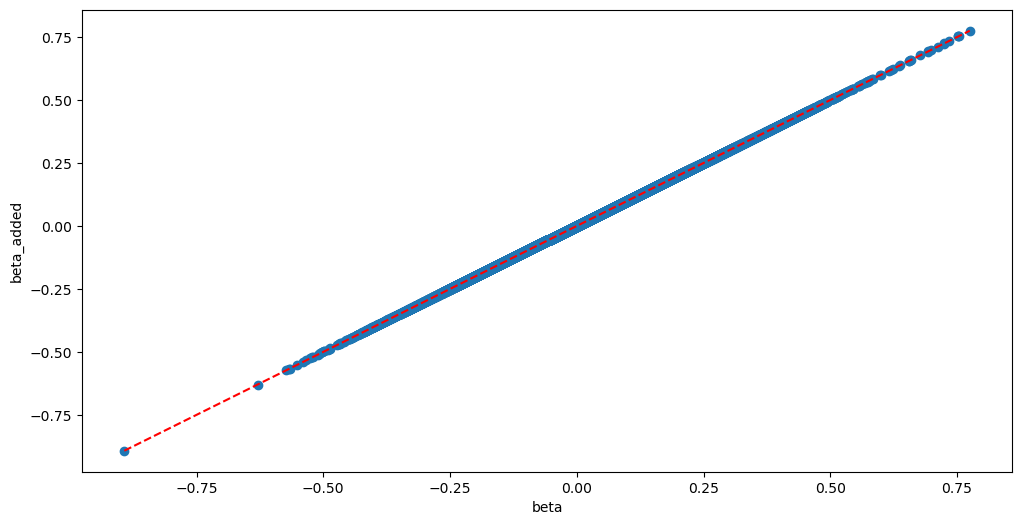

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
ax = plt.scatter(data=test, x="beta", y="beta_added")

plt.plot([test["beta"].min(), test["beta"].max()], 
         [test["beta"].min(), test["beta"].max()], 
         linestyle='--', color='red')

plt.xlabel('beta')
plt.ylabel('beta_added')
plt.show()


In [ ]:
def plot_violin_comparison(df, col1_a, col1_b, col2_a, col2_b):
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Violin plot for the first pair of columns
    sns.violinplot(data=df, x=col1_a, y=col1_b, ax=axes[0])
    axes[0].set_title(f'Comparison between {col1_a} and {col1_b}')
    
    # Violin plot for the second pair of columns
    sns.violinplot(data=df, x=col2_a, y=col2_b, ax=axes[1])
    axes[1].set_title(f'Comparison between {col2_a} and {col2_b}')

    plt.tight_layout()
    plt.show()

# Example usage
# Replace 'df' with your DataFrame and provide the column names you want to compare
plot_violin_comparison(df, 'column1', 'column2', 'column3', 'column4')


#### Plots to visualize results from ldsc

In [3]:
original_OR_ldsc_results = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/original_OR_results.csv"
original_beta_ldsc_results = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/original_beta_results.csv"
imputed_beta_ldsc_results = "/home/maria/git/SOROLLA/ROBUSTNESS_TESTS/TEST_BETA_ODDSRATIO/ldsc/imputed_beta_results.csv"


In [4]:
# # Load csv results
original_OR_ldsc_results = pd.read_csv(original_OR_ldsc_results)
original_beta_ldsc_results = pd.read_csv(original_beta_ldsc_results)
imputed_beta_ldsc_results = pd.read_csv(imputed_beta_ldsc_results)

In [9]:
def plot_correlations(df, rg_1, rg_2, pcol_1, pcol_2, label1, label2):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Scatter plot for rg values
    ax1.scatter(df[rg_1], df[rg_2], label='Data points')

    # y=x line
    ax1.plot([df[rg_1].min(), df[rg_1].max()], 
             [df[rg_1].min(), df[rg_1].max()], 
             linestyle='--', color='red')

    # Add thin grey lines at x=0 and y=0
    ax1.axhline(0, color='grey', linestyle='-', linewidth=0.5, alpha=0.5)
    ax1.axvline(0, color='grey', linestyle='-', linewidth=0.5, alpha=0.5)

    # Identify and label outliers
    for i, row in df.iterrows():
        rg_diff = abs(row[rg_1] - row[rg_2])
        if rg_diff > 0.2:  # Define a threshold for outliers
            ax1.annotate(f'{row[label1]}, {row[label2]}', (row[rg_1], row[rg_2]), fontsize=8)

    # Change color and label points with different directions
    opposite_direction_label_added = False
    for i, row in df.iterrows():
        if (row[rg_1] > 0 and row[rg_2] < 0) or (row[rg_1] < 0 and row[rg_2] > 0):
            if not opposite_direction_label_added:
                ax1.scatter(row[rg_1], row[rg_2], color='orange', label='Opposite directions')
                opposite_direction_label_added = True
            else:
                ax1.scatter(row[rg_1], row[rg_2], color='orange')
            ax1.annotate(f'{row[label1]}, {row[label2]}', (row[rg_1], row[rg_2]), fontsize=8)

    ax1.set_xlabel(rg_1)
    ax1.set_ylabel(rg_2)

    # Scatter plot for p-values
    ax2.scatter(df[pcol_1], df[pcol_2])
    ax2.plot([df[pcol_1].min(), df[pcol_1].max()], 
             [df[pcol_1].min(), df[pcol_1].max()], 
             linestyle='--', color='red')
    ax2.set_xlabel(pcol_1)
    ax2.set_ylabel(pcol_2)

    # Place the label at the bottom right
    ax1.legend(loc='lower right')

    plt.show()


In [100]:
def plot_covariances(df, gcov_int_OG_col, gcov_int_NTEST_col, gcov_int_se_OG_col, gcov_int_se_NTEST_col, label_1_col, label_2_col):
    print("COMPARISON COVARIANCES")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Scatter plot for rg values
    ax1.scatter(df[gcov_int_OG_col], df[gcov_int_NTEST_col], label='Data points')

    # y=x line
    ax1.plot([df[gcov_int_OG_col].min(), df[gcov_int_OG_col].max()], 
             [df[gcov_int_OG_col].min(), df[gcov_int_OG_col].max()], 
             linestyle='--', color='red')

    # Add thin grey lines at x=0 and y=0
    ax1.axhline(0, color='grey', linestyle='-', linewidth=0.5, alpha=0.5)
    ax1.axvline(0, color='grey', linestyle='-', linewidth=0.5, alpha=0.5)

    # Identify and label outliers
    for i, row in df.iterrows():
        rg_diff = abs(row[gcov_int_OG_col] - row[gcov_int_NTEST_col])
        if rg_diff > 0.2:  # Define a threshold for outliers
            ax1.annotate(f'{row[label_1_col]}, {row[label_2_col]}', (row[gcov_int_OG_col], row[gcov_int_NTEST_col]), fontsize=8)

    # Change color and label points with different directions
    opposite_direction_label_added = False
    for i, row in df.iterrows():
        if (row[gcov_int_OG_col] > 0 and row[gcov_int_NTEST_col] < 0) or (row[gcov_int_OG_col] < 0 and row[gcov_int_NTEST_col] > 0):
            if not opposite_direction_label_added:
                ax1.scatter(row[gcov_int_OG_col], row[gcov_int_NTEST_col], color='orange', label='Opposite directions')
                opposite_direction_label_added = True
            else:
                ax1.scatter(row[gcov_int_OG_col], row[gcov_int_NTEST_col], color='orange')
            ax1.annotate(f'{row[label_1_col]}, {row[label_2_col]}', (row[gcov_int_OG_col], row[gcov_int_NTEST_col]), fontsize=8)

    ax1.set_xlabel(gcov_int_OG_col)
    ax1.set_ylabel(gcov_int_NTEST_col)

    # Scatter plot for p-values
    ax2.scatter(df[gcov_int_se_OG_col], df[gcov_int_se_NTEST_col])
    ax2.plot([df[gcov_int_se_OG_col].min(), df[gcov_int_se_OG_col].max()], 
             [df[gcov_int_se_OG_col].min(), df[gcov_int_se_OG_col].max()], 
             linestyle='--', color='red')
    ax2.set_xlabel(gcov_int_se_OG_col)
    ax2.set_ylabel(gcov_int_se_NTEST_col)

    # Place the label at the bottom right
    ax1.legend(loc='lower right')

    plt.show()



#### 9.1. Compare original beta and OR

In [83]:
# Merge DataFrames
original_OR_beta_merged = original_OR_ldsc_results.merge(original_beta_ldsc_results, on=["label_1","id_1","label_2","id_2"], suffixes=["_original_OR", "_original_beta"])
display(original_OR_beta_merged.head())


,label_1,id_1,label_2,id_2,rg_original_OR,se_original_OR,z_original_OR,p_original_OR,h2_obs_original_OR,h2_obs_se_original_OR,h2_int_original_OR,h2_int_se_original_OR,gcov_int_original_OR,gcov_int_se_original_OR,rg_original_beta,se_original_beta,z_original_beta,p_original_beta,h2_obs_original_beta,h2_obs_se_original_beta,h2_int_original_beta,h2_int_se_original_beta,gcov_int_original_beta,gcov_int_se_original_beta
0,mdd-1,GCST009979,bcc-2,GCST90137411,-0.0394,0.0356,-1.1075,0.2681,0.0697,0.0121,0.9757,0.0236,-0.0067,0.0053,-0.0394,0.0356,-1.1075,0.2681,0.0697,0.0121,0.9757,0.0236,-0.0067,0.0053
1,mdd-1,GCST009979,multiple-sclerosis-2,GCST001198,0.0887,0.0885,1.0027,0.3160,0.1474,0.0711,1.0325,0.0158,-0.0012,0.0063,0.0887,0.0885,1.0027,0.3160,0.1474,0.0711,1.0325,0.0158,-0.0012,0.0063
2,lung-cancer-squamous,GCST004750,mdd-notrauma,GCST009981,0.0545,0.1647,0.3307,0.7409,0.0329,0.0093,1.0141,0.0066,0.0028,0.0054,0.0545,0.1647,0.3307,0.7409,0.0329,0.0093,1.0141,0.0066,0.0028,0.0054
3,lung-cancer-squamous,GCST004750,multiple-sclerosis-2,GCST001198,0.1372,0.1378,0.9955,0.3195,0.1537,0.0711,1.0289,0.0158,0.0282,0.0057,0.1372,0.1378,0.9955,0.3195,0.1537,0.0711,1.0289,0.0158,0.0282,0.0057
4,lung-cancer-squamous,GCST004750,bcc-2,GCST90137411,0.1444,0.0590,2.4462,0.0144,0.0699,0.0110,0.9751,0.0212,0.0009,0.0062,0.1444,0.0590,2.4462,0.0144,0.0699,0.0110,0.9751,0.0212,0.0009,0.0062


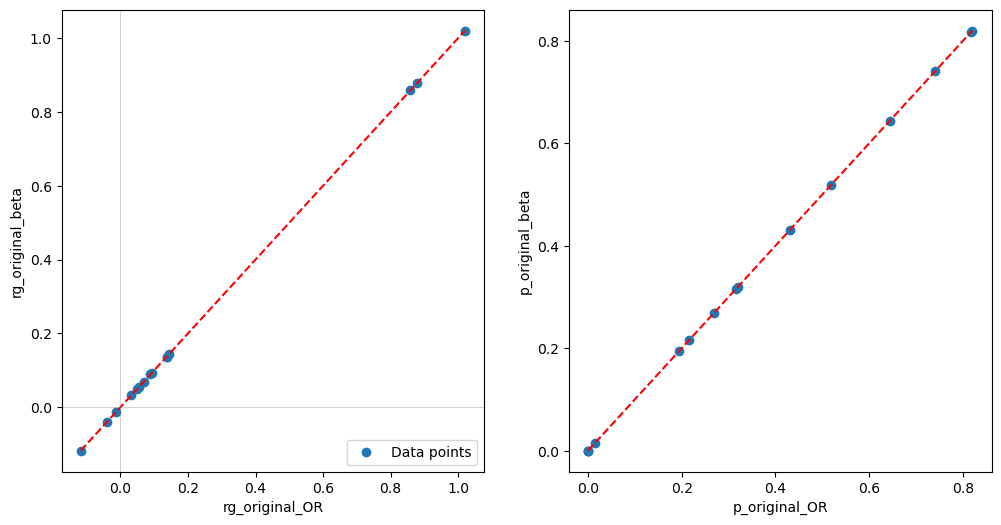

In [95]:
plot_correlations(original_OR_beta_merged, "rg_original_OR", "rg_original_beta", "p_original_OR", "p_original_beta", "label_1", "label_2")


COMPARISON COVARIANCES


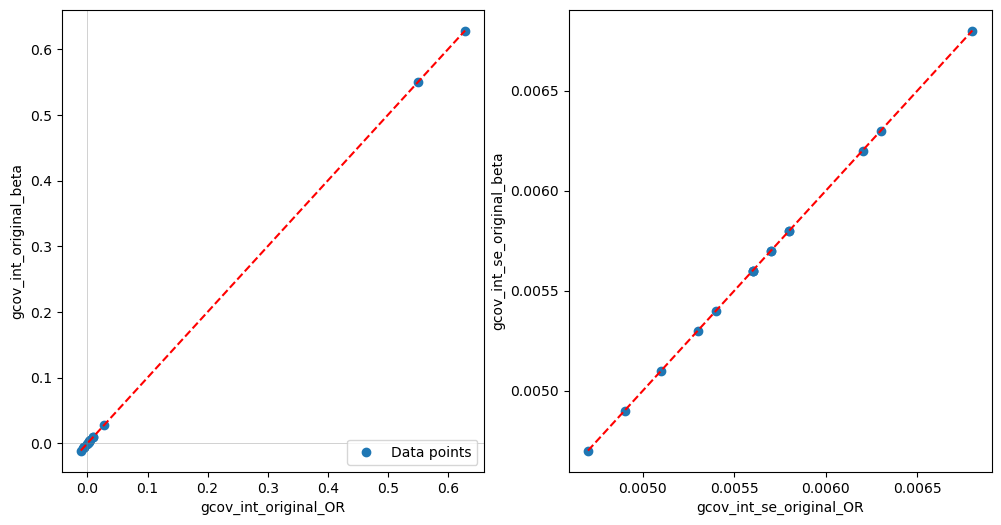

In [102]:
plot_covariances(original_OR_beta_merged, "gcov_int_original_OR", "gcov_int_original_beta", "gcov_int_se_original_OR", "gcov_int_se_original_beta", "label_1", "label_2")

#### 9.2. Compare original OR and imputed beta

In [96]:
original_OR_imputed_beta_merged = original_OR_ldsc_results.merge(imputed_beta_ldsc_results, on=["label_1","id_1","label_2","id_2"], suffixes=["_original_OR", "_imputed_beta"])
display(original_OR_imputed_beta_merged.head())

,label_1,id_1,label_2,id_2,rg_original_OR,se_original_OR,z_original_OR,p_original_OR,h2_obs_original_OR,h2_obs_se_original_OR,h2_int_original_OR,h2_int_se_original_OR,gcov_int_original_OR,gcov_int_se_original_OR,rg_imputed_beta,se_imputed_beta,z_imputed_beta,p_imputed_beta,h2_obs_imputed_beta,h2_obs_se_imputed_beta,h2_int_imputed_beta,h2_int_se_imputed_beta,gcov_int_imputed_beta,gcov_int_se_imputed_beta
0,mdd-1,GCST009979,bcc-2,GCST90137411,-0.0394,0.0356,-1.1075,0.2681,0.0697,0.0121,0.9757,0.0236,-0.006700,0.0053,-0.0394,0.0356,-1.1075,0.2681,0.0697,0.0121,0.9757,0.0236,-0.006700,0.0053
1,mdd-1,GCST009979,multiple-sclerosis-2,GCST001198,0.0887,0.0885,1.0027,0.3160,0.1474,0.0711,1.0325,0.0158,-0.001200,0.0063,0.0887,0.0885,1.0020,0.3164,0.1474,0.0711,1.0326,0.0158,-0.001200,0.0063
2,mdd-trauma,GCST009980,BIP-PGC-2011,GCST001241,0.2888,0.1174,2.4596,0.0139,0.3618,0.0427,1.0462,0.0114,0.002900,0.0070,0.2888,0.1174,2.4596,0.0139,0.3618,0.0427,1.0462,0.0114,0.002900,0.0070
3,bcc-2,GCST90137411,BIP-PGC-2021,PGC-BIP-2021,-0.0163,0.0322,-0.5050,0.6135,0.0691,0.0036,1.1052,0.0133,0.007400,0.0075,-0.0163,0.0322,-0.5050,0.6135,0.0691,0.0036,1.1052,0.0133,0.007400,0.0075
4,BIP-PGC-2021,PGC-BIP-2021,breast-carcinoma-1,GCST90011804,-0.0089,0.0462,-0.1925,0.8473,0.0249,0.0044,1.0700,0.0188,-0.000084,0.0075,-0.0089,0.0462,-0.1925,0.8473,0.0249,0.0044,1.0700,0.0188,-0.000084,0.0075


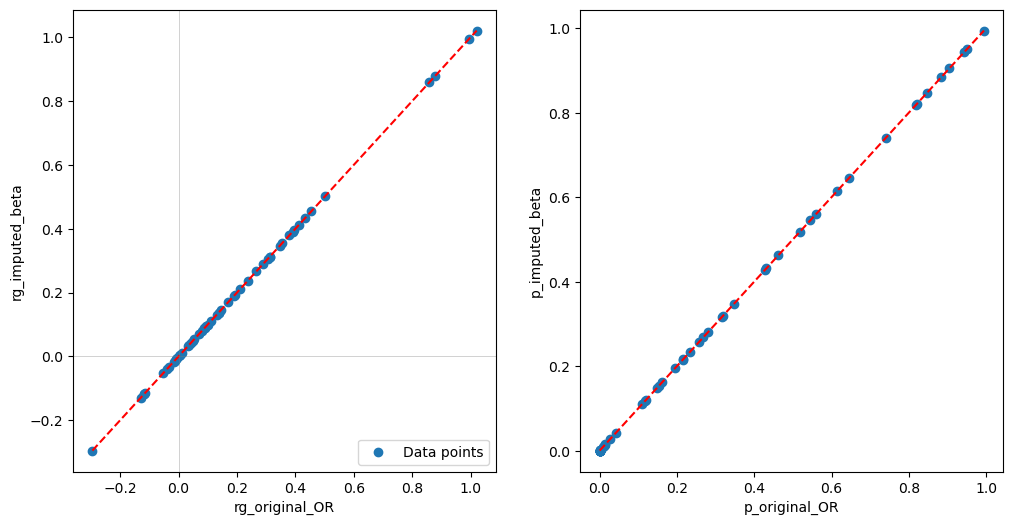

In [101]:
plot_correlations(original_OR_imputed_beta_merged, "rg_original_OR", "rg_imputed_beta", "p_original_OR", "p_imputed_beta", "label_1", "label_2")


COMPARISON COVARIANCES


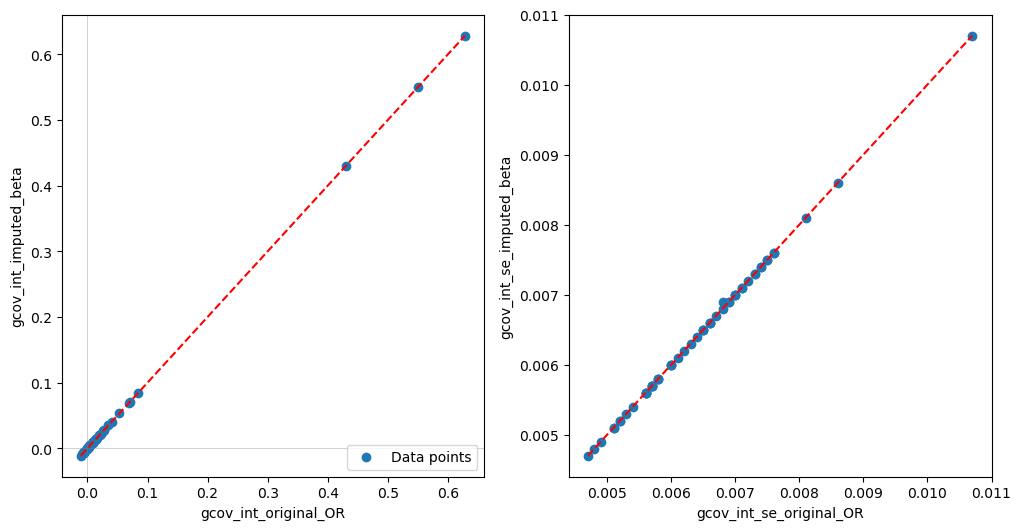

In [103]:
plot_covariances(original_OR_imputed_beta_merged, "gcov_int_original_OR", "gcov_int_imputed_beta", "gcov_int_se_original_OR", "gcov_int_se_imputed_beta", "label_1", "label_2")

#### 9.3. Compare original beta and imputed beta

In [98]:
original_beta_imputed_beta_merged = original_beta_ldsc_results.merge(imputed_beta_ldsc_results, on=["label_1","id_1","label_2","id_2"], suffixes=["_original_beta", "_imputed_beta"])
display(original_beta_imputed_beta_merged.head())

,label_1,id_1,label_2,id_2,rg_original_beta,se_original_beta,z_original_beta,p_original_beta,h2_obs_original_beta,h2_obs_se_original_beta,h2_int_original_beta,h2_int_se_original_beta,gcov_int_original_beta,gcov_int_se_original_beta,rg_imputed_beta,se_imputed_beta,z_imputed_beta,p_imputed_beta,h2_obs_imputed_beta,h2_obs_se_imputed_beta,h2_int_imputed_beta,h2_int_se_imputed_beta,gcov_int_imputed_beta,gcov_int_se_imputed_beta
0,mdd-1,GCST009979,bcc-2,GCST90137411,-0.0394,0.0356,-1.1075,0.2681,0.0697,0.0121,0.9757,0.0236,-0.0067,0.0053,-0.0394,0.0356,-1.1075,0.2681,0.0697,0.0121,0.9757,0.0236,-0.0067,0.0053
1,mdd-1,GCST009979,multiple-sclerosis-2,GCST001198,0.0887,0.0885,1.0027,0.3160,0.1474,0.0711,1.0325,0.0158,-0.0012,0.0063,0.0887,0.0885,1.0020,0.3164,0.1474,0.0711,1.0326,0.0158,-0.0012,0.0063
2,lung-cancer-squamous,GCST004750,mdd-notrauma,GCST009981,0.0545,0.1647,0.3307,0.7409,0.0329,0.0093,1.0141,0.0066,0.0028,0.0054,0.0545,0.1647,0.3307,0.7409,0.0329,0.0093,1.0141,0.0066,0.0028,0.0054
3,lung-cancer-squamous,GCST004750,multiple-sclerosis-2,GCST001198,0.1372,0.1378,0.9955,0.3195,0.1537,0.0711,1.0289,0.0158,0.0282,0.0057,0.1371,0.1377,0.9956,0.3194,0.1537,0.0710,1.0289,0.0158,0.0282,0.0057
4,lung-cancer-squamous,GCST004750,bcc-2,GCST90137411,0.1444,0.0590,2.4462,0.0144,0.0699,0.0110,0.9751,0.0212,0.0009,0.0062,0.1444,0.0590,2.4462,0.0144,0.0699,0.0110,0.9751,0.0212,0.0009,0.0062


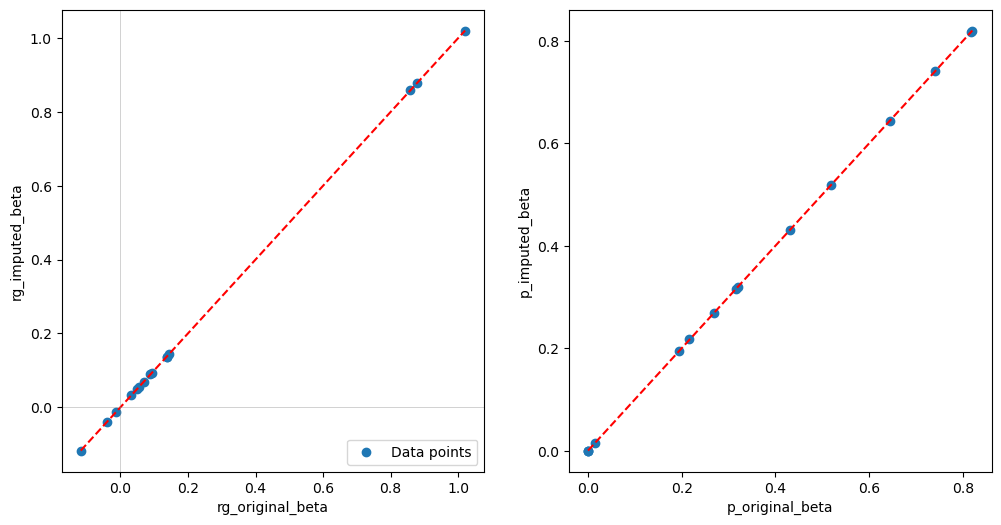

In [99]:
plot_correlations(original_beta_imputed_beta_merged, "rg_original_beta", "rg_imputed_beta", "p_original_beta", "p_imputed_beta", "label_1", "label_2")


COMPARISON COVARIANCES


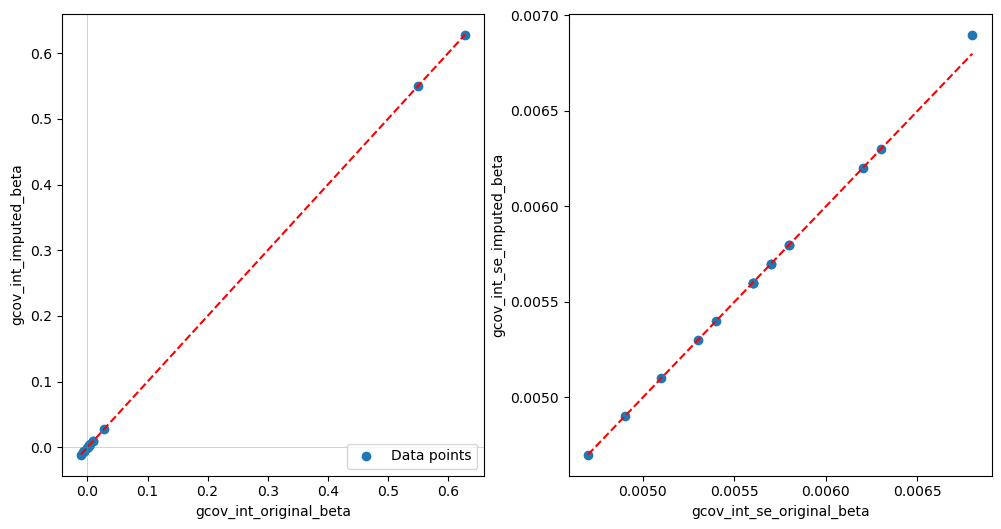

In [104]:
plot_covariances(original_beta_imputed_beta_merged, "gcov_int_original_beta", "gcov_int_imputed_beta", "gcov_int_se_original_beta", "gcov_int_se_imputed_beta", "label_1", "label_2")